# Scraped Mobile Dataset Complete EDA - Cleaning

## 1. Dataset Analysis

In [1]:
import pandas as pd

In [2]:
mobile_dataset = pd.read_csv('hamrobazaar_mobiles.csv')

In [3]:
mobile_dataset.head(5)

,title,price,location,negotiable,storage,seller_name,description,used_for,ownership_document,warranty,sim_slot,screen_size,back_camera,ram
0,Sealed Pack iPhone 13 Pro Max 512 Gb USA Silver,"रू. 1,05,000","Kholagaal, उत्तर ढोका रोड, Kathmandu-1, Kathma...",Not Negotiable,512,Easywholesale@Pvt.Ltd19 Ads\n9841351035,Sealed Pack iPhone 13 Pro Max 512 Gb USA \nSer...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Redmi All Models Emi Available 0% Intrest,"रू. 30,999","संखागर सखवा मार्ग, Lalitpur-12, ललितपुर, ललितप...",Negotiable,NaN,Shree Ganesh Mobile Hub6 Ads\n9803388018,Emi Available For All Redmi Models Starting Fr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IPHONE 11 128,"रू. 33,000","New Road, Kathmandu-22, काठमाडौं, काठमाडौँ महा...",Negotiable,NaN,STOCK SALE154 Ads\n9818960818,LIKE NEW NOT EVEN A SINGLE SCRATCH,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Samsung galaxy f22 not working,"रू. 1,699","All Core Kathmandu, Kathmandu",Negotiable,NaN,Shishir Paudel3 Ads\n9846241457,It is liquid damage set ..local repair shop to...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,iphone 15 Pro Max 256GB 98% battery Health,"रू. 1,11,999","भीमसेन स्तम्भ, Bagdurbar Marg, Kathmandu Metro...",Negotiable,NaN,INNOVATION INSTITUTE OF TECHNOLOGY CTCMALL 5TH...,iphone 15 Pro Max 256GB 98% battery Health gen...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
mobile_dataset.tail(5)

,title,price,location,negotiable,storage,seller_name,description,used_for,ownership_document,warranty,sim_slot,screen_size,back_camera,ram
949,Samsung A35 5g New Model Water Proof Ip67 8/12...,"रू. 45,899","Samsung, F84, Tenzing Chok, Budhanilkantha Mun...",Not Negotiable,128,Kapan Electronics 1386 Ads\n9849321410,Brand new\n-Display-6.60-inch \n-Front Camera-...,Brand new,NaN,1 year,NaN,NaN,NaN,8
950,iphone 12 (128gb)83% 🔋 With Box fresh condition,"रू. 54,999","People's Plaza, Khichapukhu Sadak, Kathmandu-2...",Not Negotiable,128,Peoples Mobile Hub131 Ads\n9851135126,नमस्ते 🙏🙏🙏 \nहामीसँग सबै ब्रान्डका मोबाइल फोनह...,NaN,IMEI match Box,7 Days check time,1,"Super Retina XDR OLED, HDR10, Dolby Vision, 62...","12 MP, f/1.6, 26mm (wide), 1.4µm, dual pixel P...",4
951,Realmi nazro 30 5g set (Oppo - Realme),"रू. 10,000","SalFox IT Solutions, 1043/31, Bhagwati marg, K...",Not Negotiable,128,sumit dyola 3 Ads\n9849897921,Like new not single scratches great battery ba...,Singl,No,1 week check time,Dual,": 6.5-inches FHD+ IPS LCD, 405 PPI, 90Hz refre...",48 mp,6+6=12gb
952,Samsung Galaxy S4,"रू. 2,500","Sitapaila (Nagarjun), Kathmandu",Not Negotiable,NaN,Rajendra1 Ads\n9851107936,"Condition ramro cha, all ok, kunai defect chai...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
953,vivo v11 (Vivo),"रू. 15,000","Puja Pratisthan Marg, Pushpa Nagar, Baneshwar,...",Negotiable,128,sarah13 Ads\n98******84,vivo v11,NaN,NaN,NaN,NaN,6.41 inches,"16-megapixel primary camera, and a 5-megapixel...",4


In [5]:
mobile_dataset.shape

(954, 14)

In [6]:
mobile_dataset.isnull().sum()

title                   0
price                   0
location                0
negotiable              0
storage               509
seller_name             0
description             9
used_for              689
ownership_document    767
warranty              592
sim_slot              712
screen_size           750
back_camera           706
ram                   588
dtype: int64

### 1.1 Visualization: Missing Data Analysis

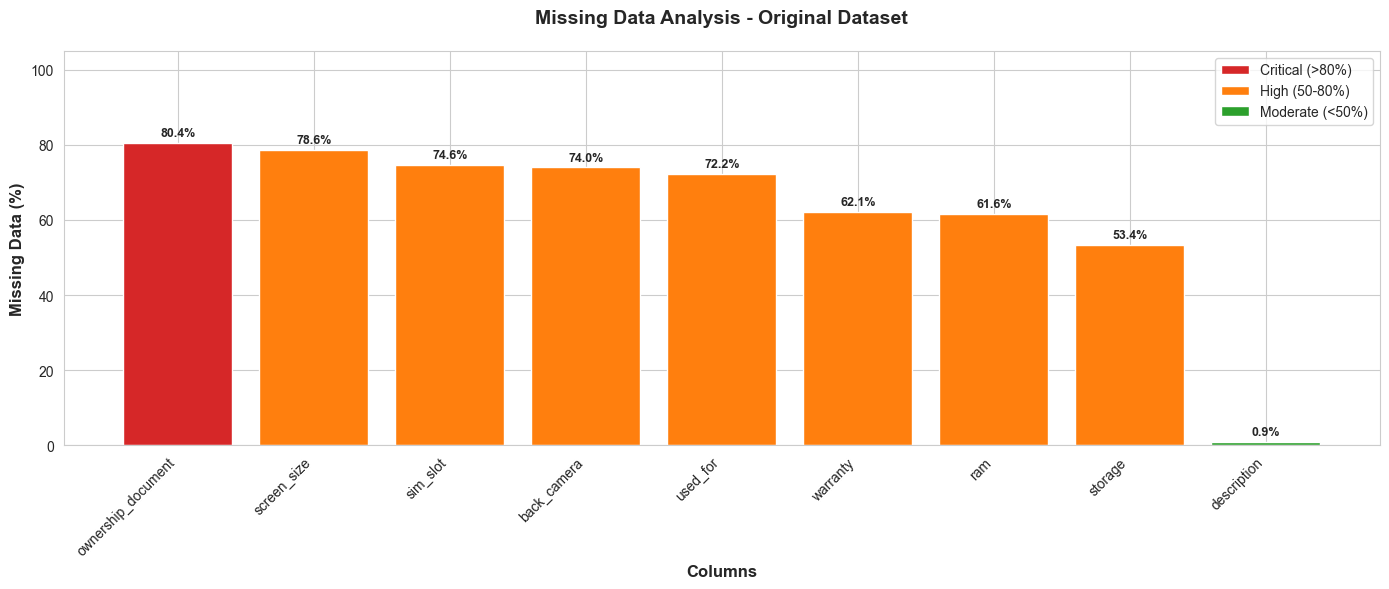


=== Missing Data Summary ===
            Column  Missing_Count  Missing_Percent
ownership_document            767        80.398323
       screen_size            750        78.616352
          sim_slot            712        74.633124
       back_camera            706        74.004193
          used_for            689        72.222222
          warranty            592        62.054507
               ram            588        61.635220
           storage            509        53.354298
       description              9         0.943396


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Calculate missing data percentage
missing_data = mobile_dataset.isnull().sum()
missing_percent = (missing_data / len(mobile_dataset)) * 100
missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing_Count': missing_data.values,
    'Missing_Percent': missing_percent.values
}).sort_values('Missing_Percent', ascending=False)

# Filter columns with missing data
missing_df_filtered = missing_df[missing_df['Missing_Count'] > 0]

# Create bar plot
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(missing_df_filtered['Column'], missing_df_filtered['Missing_Percent'], 
               color=['#d62728' if x > 80 else '#ff7f0e' if x > 50 else '#2ca02c' for x in missing_df_filtered['Missing_Percent']])

ax.set_xlabel('Columns', fontsize=12, fontweight='bold')
ax.set_ylabel('Missing Data (%)', fontsize=12, fontweight='bold')
ax.set_title('Missing Data Analysis - Original Dataset', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, 105)

# Add percentage labels on bars
for i, (bar, val) in enumerate(zip(bars, missing_df_filtered['Missing_Percent'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d62728', label='Critical (>80%)'),
    Patch(facecolor='#ff7f0e', label='High (50-80%)'),
    Patch(facecolor='#2ca02c', label='Moderate (<50%)')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n=== Missing Data Summary ===")
print(missing_df_filtered.to_string(index=False))

In [8]:
mobile_dataset.drop(columns=['ownership_document', 'sim_slot', 'used_for', 'warranty', 'seller_name'], inplace=True)
mobile_dataset.head()

,title,price,location,negotiable,storage,description,screen_size,back_camera,ram
0,Sealed Pack iPhone 13 Pro Max 512 Gb USA Silver,"रू. 1,05,000","Kholagaal, उत्तर ढोका रोड, Kathmandu-1, Kathma...",Not Negotiable,512,Sealed Pack iPhone 13 Pro Max 512 Gb USA \nSer...,NaN,NaN,NaN
1,Redmi All Models Emi Available 0% Intrest,"रू. 30,999","संखागर सखवा मार्ग, Lalitpur-12, ललितपुर, ललितप...",Negotiable,NaN,Emi Available For All Redmi Models Starting Fr...,NaN,NaN,NaN
2,IPHONE 11 128,"रू. 33,000","New Road, Kathmandu-22, काठमाडौं, काठमाडौँ महा...",Negotiable,NaN,LIKE NEW NOT EVEN A SINGLE SCRATCH,NaN,NaN,NaN
3,Samsung galaxy f22 not working,"रू. 1,699","All Core Kathmandu, Kathmandu",Negotiable,NaN,It is liquid damage set ..local repair shop to...,NaN,NaN,NaN
4,iphone 15 Pro Max 256GB 98% battery Health,"रू. 1,11,999","भीमसेन स्तम्भ, Bagdurbar Marg, Kathmandu Metro...",Negotiable,NaN,iphone 15 Pro Max 256GB 98% battery Health gen...,NaN,NaN,NaN


## 2. Column Analysis and Cleaning

### 2.1 'Price' Column Analysis and Cleaning

#### 2.1.1 'Price' column data values analysis

In [9]:
mobile_dataset['price'].value_counts()

price
रू. 25,000      18
रू. 1,39,999    15
रू. 60,000      13
रू. 75,000      12
रू. 15,000      10
                ..
रू. 1,00,999     1
रू. 2,14,999     1
रू. 40,499       1
रू. 25,999       1
रू. 1,35,999     1
Name: count, Length: 451, dtype: int64

In [10]:
mobile_dataset['price'].unique()

array(['रू. 1,05,000', 'रू. 30,999', 'रू. 33,000', 'रू. 1,699',
       'रू. 1,11,999', 'रू. 1,42,000', 'रू. 1,11,000', 'रू. 2,14,000',
       'रू. 12,000', 'रू. 2,05,000', 'रू. 21,500', 'रू. 5,500',
       'रू. 1,39,999', 'रू. 18,000', 'रू. 4,999', 'रू. 1,34,999',
       'रू. 7,500', 'रू. 1,04,999', 'रू. 16,000', 'रू. 6,200',
       'रू. 10,300', 'रू. 60,000', 'रू. 98,499', 'रू. 19,999',
       'रू. 45,000', 'रू. 28,000', 'रू. 13,500', 'रू. 2,02,000',
       'रू. 64,500', 'रू. 26,500', 'रू. 1,111', 'रू. 42,999',
       'रू. 52,999', 'रू. 1,03,999', 'रू. 42,500', 'रू. 2,200',
       'रू. 6,500', 'रू. 47,999', 'रू. 91,000', 'रू. 1,30,000',
       'रू. 2,00,000', 'रू. 1,38,999', 'रू. 2,07,999', 'रू. 65,000',
       'रू. 51,000', 'रू. 17,799', 'रू. 25,000', 'रू. 39,999',
       'रू. 11,999', 'रू. 1,22,999', 'रू. 1,700', 'रू. 5,000',
       'रू. 26,999', 'रू. 2,000', 'रू. 60,999', 'रू. 15,990',
       'रू. 1,09,999', 'रू. 1,02,999', 'रू. 37,000', 'रू. 30,000',
       'रू. 99,000', 'रू. 23,5

#### 2.1.2 Cleaning the 'Price' column by:
- Removing currency symbol using regex.
- Replacing data having two different values with their average.

In [11]:
# Clean Price column - remove Rupee symbol and handle multiple prices
import re

def clean_price(price_str):
    if pd.isna(price_str):
        return None
    
    price_str = str(price_str)
    
    # Find all numbers in the format of currency (with commas)
    pattern = r'[\d,]+'
    matches = re.findall(pattern, price_str)
    
    # Convert matched strings to integers (remove commas)
    numbers = []
    for match in matches:
        cleaned = match.replace(',', '').strip()
        if cleaned.isdigit() and len(cleaned) > 2:  # Filter out small numbers
            numbers.append(int(cleaned))
    
    # If multiple prices found, return average; otherwise return the single price
    if len(numbers) > 1:
        return sum(numbers) / len(numbers)
    elif len(numbers) == 1:
        return numbers[0]
    else:
        return None

# Apply the cleaning function
mobile_dataset['Price_Cleaned'] = mobile_dataset['price'].apply(clean_price)

# Check the results
print("Original vs Cleaned Price (first 10):")
print(mobile_dataset[['price', 'Price_Cleaned']].head(10))

Original vs Cleaned Price (first 10):
          price  Price_Cleaned
0  रू. 1,05,000       105000.0
1    रू. 30,999        30999.0
2    रू. 33,000        33000.0
3     रू. 1,699         1699.0
4  रू. 1,11,999       111999.0
5  रू. 1,42,000       142000.0
6  रू. 1,11,000       111000.0
7  रू. 2,14,000       214000.0
8    रू. 12,000        12000.0
9  रू. 2,05,000       205000.0


#### 2.1.3 Outlier Check

(array([329., 184., 123.,  84.,  63.,  43.,  59.,  17.,  30.,  20.]),
 array([1.0000e+02, 2.3090e+04, 4.6080e+04, 6.9070e+04, 9.2060e+04,
        1.1505e+05, 1.3804e+05, 1.6103e+05, 1.8402e+05, 2.0701e+05,
        2.3000e+05]),
 <BarContainer object of 10 artists>)

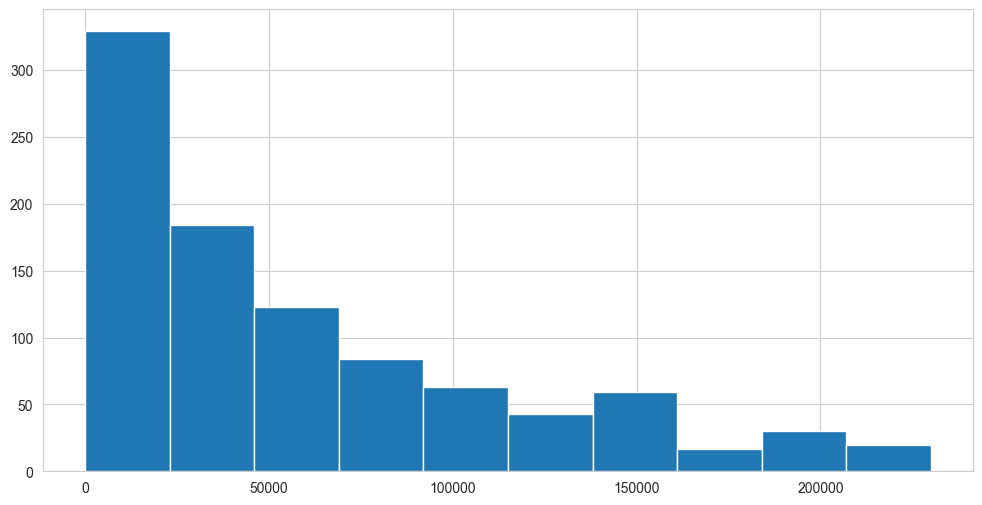

In [12]:
plt.hist(mobile_dataset['Price_Cleaned'])

{'whiskers': [<matplotlib.lines.Line2D at 0x2b836fcfe90>,
 'caps': [<matplotlib.lines.Line2D at 0x2b83941d130>,
 'boxes': [<matplotlib.lines.Line2D at 0x2b836dda9c0>],
 'medians': [<matplotlib.lines.Line2D at 0x2b83941d490>],
 'fliers': [<matplotlib.lines.Line2D at 0x2b83941d700>],
 'means': []}

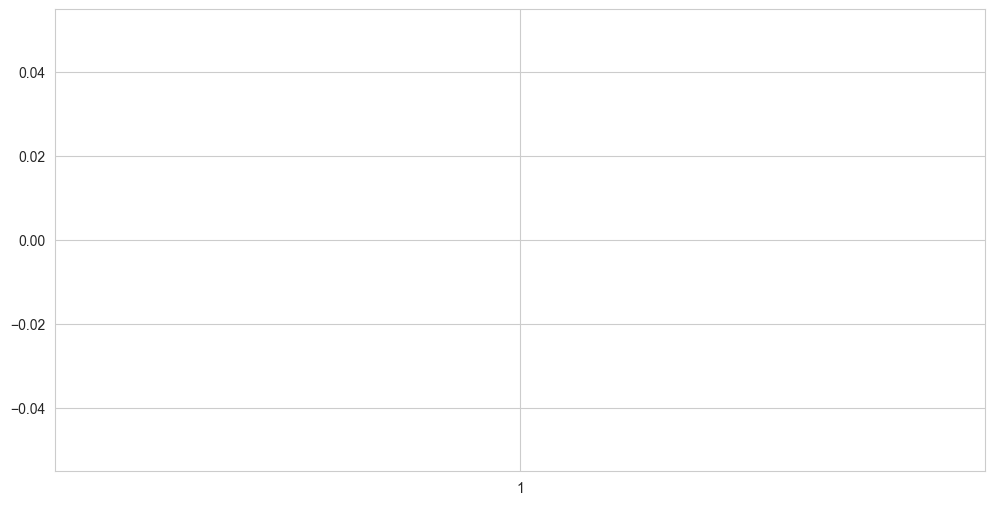

In [13]:
plt.boxplot(mobile_dataset['Price_Cleaned'])

In [14]:
mobile_dataset['Price_Cleaned'].describe()

count       952.000000
mean      60677.817227
std       56337.146211
min         100.000000
25%       16500.000000
50%       40649.000000
75%       90000.000000
max      230000.000000
Name: Price_Cleaned, dtype: float64

In [15]:
# Check for suspiciously low prices (likely errors)
print(f"\nMinimum price: {mobile_dataset['Price_Cleaned'].min()}")
print(f"\nMaximum price: {mobile_dataset['Price_Cleaned'].max()}")

low_prices = mobile_dataset[mobile_dataset['Price_Cleaned'] == mobile_dataset['Price_Cleaned'].min()][['title', 'price', 'Price_Cleaned']]
print(low_prices)
high_price = mobile_dataset[mobile_dataset['Price_Cleaned'] == mobile_dataset['Price_Cleaned'].max()][['title', 'price', 'Price_Cleaned']]
print(high_price)



Minimum price: 100.0

Maximum price: 230000.0
                                                 title    price  Price_Cleaned
236  iphone 14 pro max 256 with box charger 80% bat...  रू. 100          100.0
                                                 title         price  \
437  I Phone 17 Pro Max >17 Pro Max >17 Pro Max>Pro...  रू. 2,30,000   

     Price_Cleaned  
437       230000.0  


In [16]:
# Remove rows with unrealistic prices (< 100,000 NPR as threshold)
print(f"Dataset size before cleaning: {len(mobile_dataset)}")

mobile_dataset = mobile_dataset[mobile_dataset['Price_Cleaned'] >= 1000]

print(f"Dataset size after removing low prices: {len(mobile_dataset)}")
print(f"Rows removed: {len(mobile_dataset[mobile_dataset['Price_Cleaned'] < 100000]) if len(mobile_dataset[mobile_dataset['Price_Cleaned'] < 100000]) > 0 else 'Already cleaned'}")
print(f"\nNew minimum price: {mobile_dataset['Price_Cleaned'].min()}")

Dataset size before cleaning: 954
Dataset size after removing low prices: 948
Rows removed: 735

New minimum price: 1000.0


{'whiskers': [<matplotlib.lines.Line2D at 0x2b83903a180>,
 'caps': [<matplotlib.lines.Line2D at 0x2b83903a780>,
 'boxes': [<matplotlib.lines.Line2D at 0x2b839039f10>],
 'medians': [<matplotlib.lines.Line2D at 0x2b83903ad50>],
 'fliers': [<matplotlib.lines.Line2D at 0x2b83903b020>],
 'means': []}

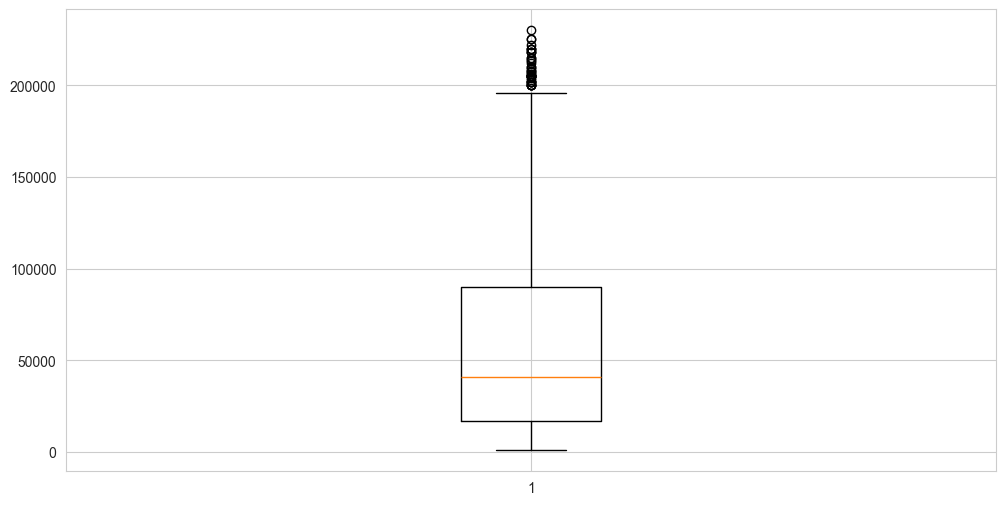

In [17]:
plt.boxplot(mobile_dataset['Price_Cleaned'])


### 2.2 'Location' Column Analysis and Cleaning

#### 2.2.1 'Location' column data values analysis

In [18]:
mobile_dataset['location'].value_counts()

location
Kholagaal, उत्तर ढोका रोड, Kathmandu-1, Kathmandu, Bagmati Pradesh                                                          33
Lagankhel, Lalitpur                                                                                                         33
Tamrakar Mobile, Pako Sadak, Kathmandu Metropolitan City, Kathmandu                                                         29
Pulchowk, Lalitpur                                                                                                          25
New Road, Kathmandu Metropolitan City, Kathmandu                                                                            21
                                                                                                                            ..
Tusal Marg, Tusal, Baudha                                                                                                    1
Lokhanthali Khaja Gar, Madhyapur Thimi-2, Bhaktapur                                                   

In [19]:
mobile_dataset['location'].unique()

array(['Kholagaal, उत्तर ढोका रोड, Kathmandu-1, Kathmandu, Bagmati Pradesh',
       'संखागर सखवा मार्ग, Lalitpur-12, ललितपुर, ललितपुर महानगरपालिका, ललितपुर, बागमती प्रदेश, 44702, नेपाल',
       'New Road, Kathmandu-22, काठमाडौं, काठमाडौँ महानगरपालिका, काठमाडौं, बाग्मती प्रदेश, 44066, नेपाल',
       'All Core Kathmandu, Kathmandu',
       'भीमसेन स्तम्भ, Bagdurbar Marg, Kathmandu Metropolitan City, Kathmandu',
       'Kathmandu City, Kathmandu', 'Pulchowk, Lalitpur',
       'Tamrakar Mobile, Pako Sadak, Kathmandu Metropolitan City, Kathmandu',
       'Kathmandu Business Park, Ganeshman Singh Path, Kathmandu-12, Kathmandu',
       'Khichapokhari, Musyakali Galli, Kathmandu-22, Kathmandu, Bagmati Pradesh',
       'Naya Gaun Paklihawa, Siddhartanagar, Siddharthanagar, Rupandehi',
       'माछापोखरी, Bypass Sadak, Kathmandu-16, Kathmandu, Bagmati Pradesh',
       'New Road, Kanti Path, Kathmandu-27, Kathmandu',
       'Dipak KTM Concern, Pako Sadak, Makkhan Tol, Yetkha, Kathmandu, Kathmandu 

#### 2.2.2 Extracting Popular Nepali Cities from Location Descriptions

The location column contains detailed address information in both English and Nepali. We'll extract the city names by:
- Searching for popular Nepali cities (major cities and districts)
- Supporting both English and Nepali (Devanagari) names
- Standardizing to English city names for consistency
- Marking locations as 'Other' if no recognized city is found

In [20]:
# Clean Location column - extract popular Nepali city names
import re

def extract_city(location_str):
    if pd.isna(location_str):
        return 'Unknown'
    
    # Convert to string and normalize
    location_str = str(location_str).strip()
    
    # List of popular Nepali cities to search for
    # Ordered by preference (more specific first)
    nepali_cities = [
        # Major cities
        'Kathmandu', 'काठमाडौं', 'काठमाडौँ',
        'Lalitpur', 'ललितपुर',
        'Bhaktapur', 'भक्तपुर',
        'Pokhara', 'पोखरा',
        'Biratnagar', 'विराटनगर',
        'Birgunj', 'बिरगंज',
        'Hetauda', 'हेटौंडा',
        'Bharatpur', 'भरतपुर',
        'Janakpur', 'जनकपुर',
        'Dharan', 'धरान',
        'Butwal', 'बुटवल',
        'Nepalgunj', 'नेपालगंज',
        'Itahari', 'इटहरी',
        'Ghorahi', 'घोराही',
        'Dhangadhi', 'धनगढी',
        'Tulsipur', 'तुलसीपुर',
        'Siddharthanagar', 'सिद्धार्थनगर', 'Siddhartanagar',
        'Rupandehi', 'रूपन्देही',
        'Bagmati', 'बागमती', 'बाग्मती',
        'Chitwan', 'चितवन',
        'Kaski', 'कास्की',
        'Morang', 'मोरंग',
        'Sunsari', 'सुनसरी',
        'Kailali', 'कैलाली',
        'Kanchanpur', 'कञ्चनपुर',
        'Dang', 'दाङ',
        'Banke', 'बाँके',
        'Parsa', 'पर्सा',
        'Makwanpur', 'मकवानपुर',
        'Nawalpur', 'नवलपुर',
        'Jhapa', 'झापा',
        'Ilam', 'इलाम',
        'Syangja', 'स्याङ्जा',
        'Tanahu', 'तनहुँ',
        'Gorkha', 'गोरखा',
        'Palpa', 'पाल्पा',
        'Gulmi', 'गुल्मी',
        'Arghakhanchi', 'अर्घाखाँची',
        'Kapilvastu', 'कपिलवस्तु',
        'Dadeldhura', 'डडेलधुरा',
        'Doti', 'डोटी',
        'Surkhet', 'सुर्खेत'
    ]
    
    # Search for city names (case-insensitive for English, exact for Nepali)
    for city in nepali_cities:
        # Create pattern that matches word boundaries
        pattern = r'\b' + re.escape(city) + r'\b'
        if re.search(pattern, location_str, re.IGNORECASE):
            # Return the standardized English name
            if city in ['Kathmandu', 'काठमाडौं', 'काठमाडौँ']:
                return 'Kathmandu'
            elif city in ['Lalitpur', 'ललितपुर']:
                return 'Lalitpur'
            elif city in ['Bhaktapur', 'भक्तपुर']:
                return 'Bhaktapur'
            elif city in ['Pokhara', 'पोखरा']:
                return 'Pokhara'
            elif city in ['Biratnagar', 'विराटनगर']:
                return 'Biratnagar'
            elif city in ['Birgunj', 'बिरगंज']:
                return 'Birgunj'
            elif city in ['Hetauda', 'हेटौंडा']:
                return 'Hetauda'
            elif city in ['Bharatpur', 'भरतपुर']:
                return 'Bharatpur'
            elif city in ['Janakpur', 'जनकपुर']:
                return 'Janakpur'
            elif city in ['Dharan', 'धरान']:
                return 'Dharan'
            elif city in ['Butwal', 'बुटवल']:
                return 'Butwal'
            elif city in ['Nepalgunj', 'नेपालगंज']:
                return 'Nepalgunj'
            elif city in ['Itahari', 'इटहरी']:
                return 'Itahari'
            elif city in ['Ghorahi', 'घोराही']:
                return 'Ghorahi'
            elif city in ['Dhangadhi', 'धनगढी']:
                return 'Dhangadhi'
            elif city in ['Tulsipur', 'तुलसीपुर']:
                return 'Tulsipur'
            elif city in ['Siddharthanagar', 'सिद्धार्थनगर', 'Siddhartanagar']:
                return 'Siddharthanagar'
            elif city in ['Rupandehi', 'रूपन्देही']:
                return 'Rupandehi'
            elif city in ['Bagmati', 'बागमती', 'बाग्मती']:
                return 'Bagmati'
            elif city in ['Chitwan', 'चितवन']:
                return 'Chitwan'
            elif city in ['Kaski', 'कास्की']:
                return 'Kaski'
            elif city in ['Morang', 'मोरंग']:
                return 'Morang'
            elif city in ['Sunsari', 'सुनसरी']:
                return 'Sunsari'
            elif city in ['Kailali', 'कैलाली']:
                return 'Kailali'
            elif city in ['Kanchanpur', 'कञ्चनपुर']:
                return 'Kanchanpur'
            elif city in ['Dang', 'दाङ']:
                return 'Dang'
            elif city in ['Banke', 'बाँके']:
                return 'Banke'
            elif city in ['Parsa', 'पर्सा']:
                return 'Parsa'
            elif city in ['Makwanpur', 'मकवानपुर']:
                return 'Makwanpur'
            elif city in ['Nawalpur', 'नवलपुर']:
                return 'Nawalpur'
            elif city in ['Jhapa', 'झापा']:
                return 'Jhapa'
            elif city in ['Ilam', 'इलाम']:
                return 'Ilam'
            elif city in ['Syangja', 'स्याङ्जा']:
                return 'Syangja'
            elif city in ['Tanahu', 'तनहुँ']:
                return 'Tanahu'
            elif city in ['Gorkha', 'गोरखा']:
                return 'Gorkha'
            elif city in ['Palpa', 'पाल्पा']:
                return 'Palpa'
            elif city in ['Gulmi', 'गुल्मी']:
                return 'Gulmi'
            elif city in ['Arghakhanchi', 'अर्घाखाँची']:
                return 'Arghakhanchi'
            elif city in ['Kapilvastu', 'कपिलवस्तु']:
                return 'Kapilvastu'
            elif city in ['Dadeldhura', 'डडेलधुरा']:
                return 'Dadeldhura'
            elif city in ['Doti', 'डोटी']:
                return 'Doti'
            elif city in ['Surkhet', 'सुर्खेत']:
                return 'Surkhet'
    
    # If no city found, return 'Other'
    return 'Other'

# Apply cleaning
mobile_dataset['Location_City'] = mobile_dataset['location'].apply(extract_city)

print("\nExtracted city names:")
print(mobile_dataset['Location_City'].value_counts())
print(f"\nTotal unique cities: {mobile_dataset['Location_City'].nunique()}")
print(f"Unknown/Other locations: {len(mobile_dataset[mobile_dataset['Location_City'].isin(['Unknown', 'Other'])])}")


Extracted city names:
Location_City
Kathmandu          631
Lalitpur           195
Other               61
Bhaktapur           28
Pokhara              7
Butwal               5
Jhapa                4
Hetauda              4
Birgunj              4
Siddharthanagar      1
Dharan               1
Biratnagar           1
Dang                 1
Kailali              1
Bharatpur            1
Surkhet              1
Nepalgunj            1
Janakpur             1
Name: count, dtype: int64

Total unique cities: 18
Unknown/Other locations: 61


#### 2.2.3 Visualization: Location Distribution by City

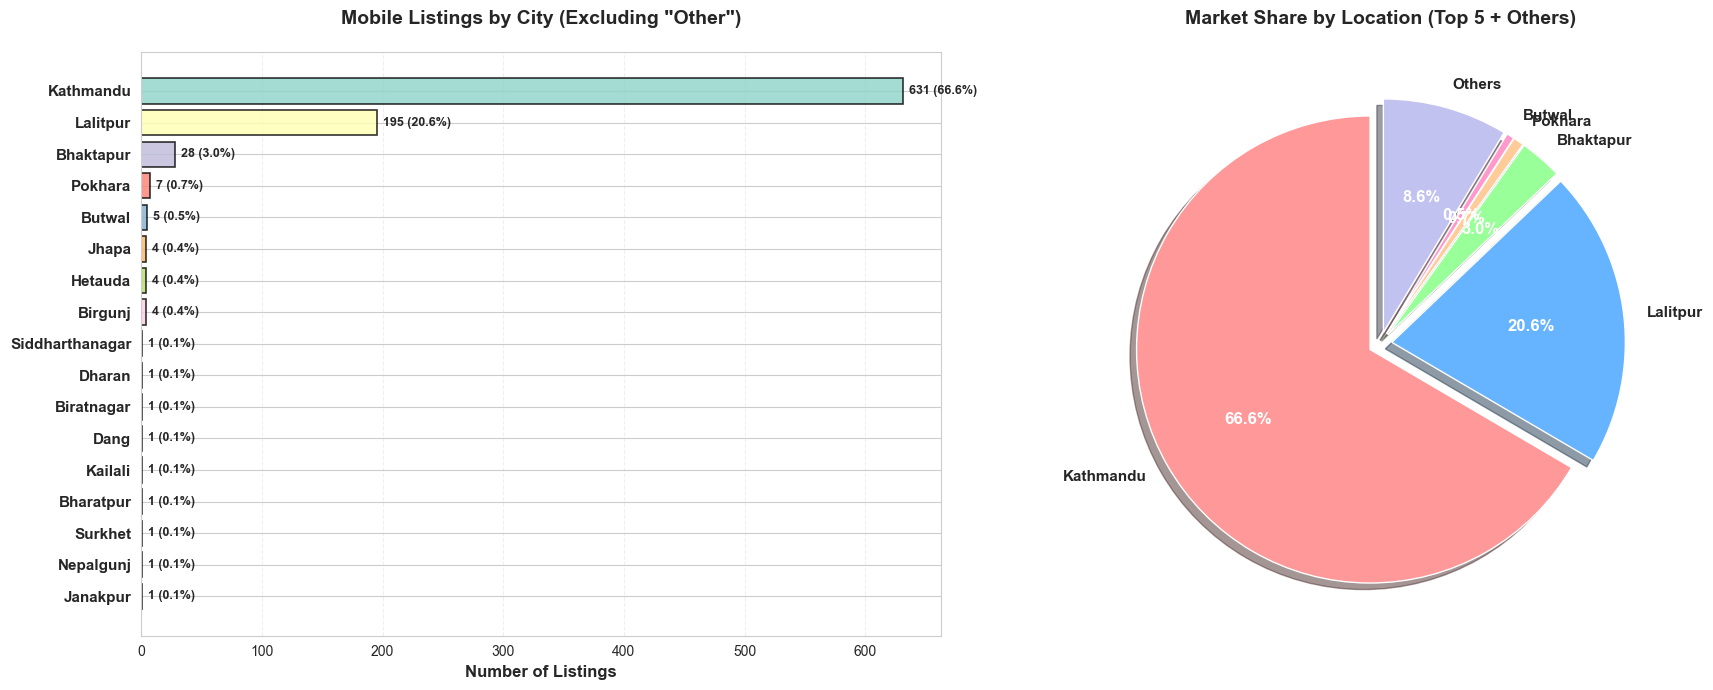


=== Location Distribution Summary ===
Total listings: 948
Total unique cities identified: 18

Top 5 cities by listing count:
  1. Kathmandu: 631 listings (66.6%)
  2. Lalitpur: 195 listings (20.6%)
  3. Other: 61 listings (6.4%)
  4. Bhaktapur: 28 listings (3.0%)
  5. Pokhara: 7 listings (0.7%)

Other/Unidentified locations: 61 listings (6.4%)

Kathmandu Valley (Kathmandu + Lalitpur + Bhaktapur): 854 listings (90.1%)


In [21]:
# Visualize location distribution by city
location_counts = mobile_dataset['Location_City'].value_counts()

# Filter out 'Other' for main visualization (show it separately)
location_counts_main = location_counts[location_counts.index != 'Other']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart for top cities
colors_palette = plt.cm.Set3(range(len(location_counts_main)))
bars = ax1.barh(range(len(location_counts_main)), location_counts_main.values, color=colors_palette, alpha=0.8, edgecolor='black', linewidth=1.2)
ax1.set_yticks(range(len(location_counts_main)))
ax1.set_yticklabels(location_counts_main.index, fontsize=11, fontweight='bold')
ax1.set_xlabel('Number of Listings', fontsize=12, fontweight='bold')
ax1.set_title('Mobile Listings by City (Excluding "Other")', fontsize=14, fontweight='bold', pad=20)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.invert_yaxis()  # Highest at top

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, location_counts_main.values)):
    width = bar.get_width()
    ax1.text(width + 5, bar.get_y() + bar.get_height()/2.,
             f'{int(val)} ({val/len(mobile_dataset)*100:.1f}%)',
             ha='left', va='center', fontsize=9, fontweight='bold')

# Pie chart for major cities (top 5) + Others combined
top_cities = location_counts_main.head(5)
others_count = location_counts_main[5:].sum() + location_counts.get('Other', 0)

pie_data = list(top_cities.values) + [others_count]
pie_labels = list(top_cities.index) + ['Others']
colors_pie = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc', '#c2c2f0']

wedges, texts, autotexts = ax2.pie(pie_data, 
                                     labels=pie_labels,
                                     autopct='%1.1f%%',
                                     colors=colors_pie,
                                     explode=[0.05] * len(pie_data),
                                     startangle=90,
                                     textprops={'fontsize': 11, 'fontweight': 'bold'},
                                     shadow=True)

# Make percentage text white and bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

ax2.set_title('Market Share by Location (Top 5 + Others)', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n=== Location Distribution Summary ===")
print(f"Total listings: {len(mobile_dataset)}")
print(f"Total unique cities identified: {mobile_dataset['Location_City'].nunique()}")
print(f"\nTop 5 cities by listing count:")
for i, (city, count) in enumerate(location_counts.head(5).items(), 1):
    percentage = count/len(mobile_dataset)*100
    print(f"  {i}. {city}: {count} listings ({percentage:.1f}%)")

print(f"\nOther/Unidentified locations: {location_counts.get('Other', 0)} listings ({location_counts.get('Other', 0)/len(mobile_dataset)*100:.1f}%)")

# Calculate Kathmandu Valley share (Kathmandu + Lalitpur + Bhaktapur)
valley_cities = ['Kathmandu', 'Lalitpur', 'Bhaktapur']
valley_count = sum([location_counts.get(city, 0) for city in valley_cities])
print(f"\nKathmandu Valley (Kathmandu + Lalitpur + Bhaktapur): {valley_count} listings ({valley_count/len(mobile_dataset)*100:.1f}%)")

In [22]:
# Show examples of city extraction
print("=== Examples of City Extraction ===\n")
sample_df = mobile_dataset[['location', 'Location_City']].head(5)
for idx, row in sample_df.iterrows():
    print(f"Original: {row['location'][:80]}...")
    print(f"Extracted City: {row['Location_City']}")
    print("-" * 80)

=== Examples of City Extraction ===

Original: Kholagaal, उत्तर ढोका रोड, Kathmandu-1, Kathmandu, Bagmati Pradesh...
Extracted City: Kathmandu
--------------------------------------------------------------------------------
Original: संखागर सखवा मार्ग, Lalitpur-12, ललितपुर, ललितपुर महानगरपालिका, ललितपुर, बागमती प...
Extracted City: Lalitpur
--------------------------------------------------------------------------------
Original: New Road, Kathmandu-22, काठमाडौं, काठमाडौँ महानगरपालिका, काठमाडौं, बाग्मती प्रदे...
Extracted City: Kathmandu
--------------------------------------------------------------------------------
Original: All Core Kathmandu, Kathmandu...
Extracted City: Kathmandu
--------------------------------------------------------------------------------
Original: भीमसेन स्तम्भ, Bagdurbar Marg, Kathmandu Metropolitan City, Kathmandu...
Extracted City: Kathmandu
--------------------------------------------------------------------------------


In [23]:
# Drop rows where city couldn't be extracted
mobile_dataset = mobile_dataset[mobile_dataset['Location_City'] != 'Other']

print(f"Dataset size after dropping 'Other' locations: {len(mobile_dataset)}")
print(f"\nRemaining cities:")
print(mobile_dataset['Location_City'].value_counts())

Dataset size after dropping 'Other' locations: 887

Remaining cities:
Location_City
Kathmandu          631
Lalitpur           195
Bhaktapur           28
Pokhara              7
Butwal               5
Jhapa                4
Hetauda              4
Birgunj              4
Siddharthanagar      1
Dharan               1
Biratnagar           1
Dang                 1
Kailali              1
Bharatpur            1
Surkhet              1
Nepalgunj            1
Janakpur             1
Name: count, dtype: int64


#### 2.2.4 Encoding Location_City Column

In [24]:
# Encode Location_City using Label Encoding
from sklearn.preprocessing import LabelEncoder

le_location = LabelEncoder()
mobile_dataset['Location_City_Encoded'] = le_location.fit_transform(mobile_dataset['Location_City'])

print("Location_City_Encoded column created!")
print("\n--- City Encoding Mapping ---")
for i, city_name in enumerate(le_location.classes_):
    print(f"{city_name}: {i}")

print("\n--- Sample Data ---")
print(mobile_dataset[['Location_City', 'Location_City_Encoded']].head())

Location_City_Encoded column created!

--- City Encoding Mapping ---
Bhaktapur: 0
Bharatpur: 1
Biratnagar: 2
Birgunj: 3
Butwal: 4
Dang: 5
Dharan: 6
Hetauda: 7
Janakpur: 8
Jhapa: 9
Kailali: 10
Kathmandu: 11
Lalitpur: 12
Nepalgunj: 13
Pokhara: 14
Siddharthanagar: 15
Surkhet: 16

--- Sample Data ---
  Location_City  Location_City_Encoded
0     Kathmandu                     11
1      Lalitpur                     12
2     Kathmandu                     11
3     Kathmandu                     11
4     Kathmandu                     11


### 2.3 'negotiable' Column Analysis and Cleaning

#### 2.3.1 'negotiable' Column data values analysis

In [25]:
mobile_dataset['negotiable'].value_counts()

negotiable
Not Negotiable    586
Negotiable        301
Name: count, dtype: int64

#### 2.3.2 Encoding 'negotiable' Column

In [26]:
# Encode negotiable column
# Map: Negotiable -> 1, Not Negotiable -> 0
mobile_dataset['negotiable_encoded'] = mobile_dataset['negotiable'].map({
    'Negotiable': 1,
    'Not Negotiable': 0
})

print("negotiable_encoded column created!")
print("\n--- Encoding Mapping ---")
print("Negotiable: 1")
print("Not Negotiable: 0")

print("\n--- Value Counts ---")
print(mobile_dataset['negotiable_encoded'].value_counts())

print("\n--- Sample Data ---")
print(mobile_dataset[['negotiable', 'negotiable_encoded']].head(10))

negotiable_encoded column created!

--- Encoding Mapping ---
Negotiable: 1
Not Negotiable: 0

--- Value Counts ---
negotiable_encoded
0    586
1    301
Name: count, dtype: int64

--- Sample Data ---
       negotiable  negotiable_encoded
0  Not Negotiable                   0
1      Negotiable                   1
2      Negotiable                   1
3      Negotiable                   1
4      Negotiable                   1
5  Not Negotiable                   0
6  Not Negotiable                   0
7  Not Negotiable                   0
8  Not Negotiable                   0
9      Negotiable                   1


### 2.4 'Storage' Column Analysis and Cleaning

#### 2.4.1 'Storage' column data values analysis

In [27]:
mobile_dataset['storage'].unique()

array(['512', nan, '256', '128', '64 GB', '256Gb', '0', '512 gb', '256gb',
       '512gb', '256 GB', '265', '128GB', '126GB', '128 GB', '128gb',
       '512GB', '512 GB', '64', '16', '32', '16 Gb', '8', '256GB', '10',
       '126 Gb', '64GB', '12', '11', '1', '128B', '128Gb', '32gb',
       '128 Gb', '32GB', '34', '32 GB', '2', '100'], dtype=object)

In [28]:
mobile_dataset['storage'].value_counts()

storage
256       144
128       111
64         32
512        21
128GB      14
128 GB     12
256 GB     10
256gb      10
32          7
64 GB       5
128gb       5
256Gb       5
10          4
512GB       4
256GB       3
512gb       3
11          3
32gb        2
12          2
512 GB      2
16          2
2           2
0           1
8           1
265         1
126GB       1
512 gb      1
16 Gb       1
64GB        1
126 Gb      1
128B        1
1           1
128 Gb      1
128Gb       1
32GB        1
34          1
32 GB       1
100         1
Name: count, dtype: int64

#### 2.4.2 Cleaning Storage Column - Extract Values and Convert to GB

In [29]:
# Clean Storage column - extract numeric values and convert to GB
import re

def clean_storage(storage_str):
    if pd.isna(storage_str):
        return None
    
    storage_str = str(storage_str).strip()
    
    # Extract numeric value using regex
    pattern = r'(\d+\.?\d*)'
    match = re.search(pattern, storage_str)
    
    if match:
        value = float(match.group(1))
        return value
    else:
        return None

# Apply cleaning
mobile_dataset['Storage_GB'] = mobile_dataset['storage'].apply(clean_storage)

print("Storage column cleaned!")
print(f"\nNull values: {mobile_dataset['Storage_GB'].isna().sum()}")
print("\n--- Sample Data ---")
print(mobile_dataset[['storage', 'Storage_GB']].head(20))
print("\n--- Unique Values ---")
print(sorted(mobile_dataset['Storage_GB'].dropna().unique()))

Storage column cleaned!

Null values: 468

--- Sample Data ---
   storage  Storage_GB
0      512       512.0
1      NaN         NaN
2      NaN         NaN
3      NaN         NaN
4      NaN         NaN
5      256       256.0
6      NaN         NaN
7      256       256.0
8      NaN         NaN
9      NaN         NaN
10     128       128.0
11     NaN         NaN
12     256       256.0
13     NaN         NaN
14     NaN         NaN
15     256       256.0
16     NaN         NaN
17     128       128.0
19   64 GB        64.0
20     NaN         NaN

--- Unique Values ---
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(8.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(16.0), np.float64(32.0), np.float64(34.0), np.float64(64.0), np.float64(100.0), np.float64(126.0), np.float64(128.0), np.float64(256.0), np.float64(265.0), np.float64(512.0)]


#### 2.4.3 Identifying Suspicious Storage Values

Realistic mobile phone storage sizes:
- **Common values**: 16GB, 32GB, 64GB, 128GB, 256GB, 512GB, 1TB (1024GB)
- **Minimum realistic**: 8 GB (very old/basic phones)
- **Maximum realistic**: 1024 GB (1TB for high-end phones)

Suspicious values to investigate:
- Values < 8 GB (0, 1, 2 are likely errors)
- Odd values like 10, 11, 12, 34, 100, 126, 265 (not standard storage sizes)

In [30]:
# Identify suspicious storage values
# Valid phone storage sizes: 8, 16, 32, 64, 128, 256, 512, 1024 GB
valid_storage_sizes = [8, 16, 32, 64, 128, 256, 512, 1024]

print("=== Suspicious Storage Values Analysis ===\n")

# Find values that are not in the valid list
suspicious_mask = ~mobile_dataset['Storage_GB'].isin(valid_storage_sizes) & mobile_dataset['Storage_GB'].notna()
suspicious_values = mobile_dataset[suspicious_mask]

print(f"Total suspicious values: {len(suspicious_values)}")
print(f"Percentage of dataset: {len(suspicious_values)/len(mobile_dataset)*100:.2f}%\n")

# Show suspicious value distribution
print("--- Suspicious Value Distribution ---")
print(suspicious_values['Storage_GB'].value_counts().sort_index())

# Show examples of suspicious values
print("\n--- Examples of Suspicious Storage Values ---")
print(suspicious_values[['title', 'storage', 'Storage_GB']].head(15))

# Show summary statistics
print("\n--- Valid vs Suspicious Storage Values ---")
print(f"Valid storage values: {mobile_dataset['Storage_GB'].isin(valid_storage_sizes).sum()}")
print(f"Suspicious storage values: {len(suspicious_values)}")
print(f"Null values: {mobile_dataset['Storage_GB'].isna().sum()}")

=== Suspicious Storage Values Analysis ===

Total suspicious values: 18
Percentage of dataset: 2.03%

--- Suspicious Value Distribution ---
Storage_GB
0.0      1
1.0      1
2.0      2
10.0     4
11.0     3
12.0     2
34.0     1
100.0    1
126.0    2
265.0    1
Name: count, dtype: int64

--- Examples of Suspicious Storage Values ---
                                                 title storage  Storage_GB
37                                    nokia 1100 model       0         0.0
74                                 Oneplus 8t 12/256gb     265       265.0
82                    Redmi 10 2022 Smart Mobile Phone   126GB       126.0
339  Narzo(realme) 50i 2gb Ram 32gb Rom , (Oppo - R...      10        10.0
425                                 Iphone 16 (126 GB)  126 Gb       126.0
470  Samsung A12 4gb Ram 128gb Rom Brand New (Samsung)      12        12.0
483  Samsung A12 4gb Ram 64gb Rom With 1year Warran...      11        11.0
532  Samsung M02 2gb Ram 32gb Rom 1year Warranty (S...      10    

#### 2.4.3 Replacing Suspicious Values with Nearest Valid Storage Size

In [31]:
# Replace suspicious storage values with nearest valid size
import numpy as np

def find_nearest_valid_storage(value):
    """Find the nearest valid storage size for a given value"""
    if pd.isna(value):
        return None
    
    valid_storage_sizes = [8, 16, 32, 64, 128, 256, 512, 1024]
    
    # If already valid, return as is
    if value in valid_storage_sizes:
        return value
    
    # Find nearest valid size
    nearest = min(valid_storage_sizes, key=lambda x: abs(x - value))
    return nearest

# Apply correction
mobile_dataset['Storage_GB_Corrected'] = mobile_dataset['Storage_GB'].apply(find_nearest_valid_storage)

print("=== Storage Values Correction Summary ===\n")

# Show what changed
changed_mask = (mobile_dataset['Storage_GB'] != mobile_dataset['Storage_GB_Corrected']) & mobile_dataset['Storage_GB'].notna()
changed_values = mobile_dataset[changed_mask]

if len(changed_values) > 0:
    print(f"Total values corrected: {len(changed_values)}\n")
    print("--- Examples of Corrections ---")
    print(changed_values[['storage', 'Storage_GB', 'Storage_GB_Corrected']].head(15))
    
    print("\n--- Correction Mapping ---")
    correction_summary = changed_values.groupby(['Storage_GB', 'Storage_GB_Corrected']).size().reset_index(name='count')
    for _, row in correction_summary.iterrows():
        print(f"{row['Storage_GB']} GB → {row['Storage_GB_Corrected']} GB ({row['count']} values)")
else:
    print("No corrections needed - all values are valid!")

print(f"\n--- Final Storage Distribution ---")
print(mobile_dataset['Storage_GB_Corrected'].value_counts().sort_index())

=== Storage Values Correction Summary ===

Total values corrected: 18

--- Examples of Corrections ---
    storage  Storage_GB  Storage_GB_Corrected
37        0         0.0                   8.0
74      265       265.0                 256.0
82    126GB       126.0                 128.0
339      10        10.0                   8.0
425  126 Gb       126.0                 128.0
470      12        12.0                   8.0
483      11        11.0                   8.0
532      10        10.0                   8.0
544      11        11.0                   8.0
545       1         1.0                   8.0
651      11        11.0                   8.0
670      10        10.0                   8.0
761      10        10.0                   8.0
802      34        34.0                  32.0
877      12        12.0                   8.0

--- Correction Mapping ---
0.0 GB → 8.0 GB (1.0 values)
1.0 GB → 8.0 GB (1.0 values)
2.0 GB → 8.0 GB (2.0 values)
10.0 GB → 8.0 GB (4.0 values)
11.0 GB → 8.0 GB

#### 2.4.4 Fill Null Storage Values from Description Column
- Extract storage information from description column
- Look for storage space mentions (>=32GB)
- Fill null Storage_GB_Corrected values

In [32]:
import re
import numpy as np

# First, let's check how many null values we have
print("=== Storage Null Values Analysis ===\n")
null_storage = mobile_dataset['Storage_GB_Corrected'].isna().sum()
print(f"Total null Storage_GB_Corrected values: {null_storage}")
print(f"Percentage: {(null_storage/len(mobile_dataset)*100):.2f}%\n")

# Function to extract storage from description
def extract_storage_from_description(desc):
    """
    Extract storage information from description text.
    Looks for patterns like: 64GB, 128 GB, 256gb, etc.
    Only considers storage >= 32GB (as these are likely phone storage, not RAM)
    """
    if pd.isna(desc):
        return None
    
    desc = str(desc).upper()  # Convert to uppercase for consistency
    
    # Pattern to match storage: number followed by GB (with optional space)
    # Looks for patterns like: 64GB, 128 GB, 256gb, etc.
    pattern = r'(\d+)\s*GB'
    
    matches = re.findall(pattern, desc)
    
    if matches:
        # Convert to integers
        storage_values = [int(x) for x in matches]
        
        # Filter for values >= 32GB (phone storage, not RAM)
        # Valid phone storage sizes
        valid_sizes = [32, 64, 128, 256, 512, 1024]
        
        # Find storage values that match valid sizes
        valid_storage = [s for s in storage_values if s in valid_sizes]
        
        if valid_storage:
            # If multiple valid values found, return the largest (likely the actual storage)
            return float(max(valid_storage))
    
    return None

# Apply extraction to rows with null Storage_GB_Corrected
print("Extracting storage from descriptions...\n")

# Create a mask for null storage values
null_mask = mobile_dataset['Storage_GB_Corrected'].isna()

# Extract storage from description for null values
extracted_storage = mobile_dataset.loc[null_mask, 'description'].apply(extract_storage_from_description)

# Count how many we can fill
fillable_count = extracted_storage.notna().sum()
print(f"Storage values extracted from description: {fillable_count}")
print(f"Percentage of nulls that can be filled: {(fillable_count/null_storage*100):.2f}%\n")

# Show some examples before filling
print("=== Examples of Extraction ===\n")
examples = mobile_dataset.loc[null_mask & extracted_storage.notna(), ['title', 'description', 'Storage_GB_Corrected']].head(10)
examples['Extracted_Storage'] = extracted_storage[extracted_storage.notna()].head(10).values
print(examples[['title', 'Extracted_Storage']].to_string(index=False))

# Fill the null values
print("\n\n=== Filling Null Storage Values ===\n")
before_fill = mobile_dataset['Storage_GB_Corrected'].isna().sum()

# Create a new column to track which values were filled
mobile_dataset['Storage_Filled_From_Desc'] = False

# Fill the null values from description
mobile_dataset.loc[null_mask, 'Storage_GB_Corrected'] = mobile_dataset.loc[null_mask, 'Storage_GB_Corrected'].fillna(extracted_storage)

# Mark which values were filled
mobile_dataset.loc[null_mask & extracted_storage.notna(), 'Storage_Filled_From_Desc'] = True

after_fill = mobile_dataset['Storage_GB_Corrected'].isna().sum()

print(f"Null values before filling: {before_fill}")
print(f"Null values after filling: {after_fill}")
print(f"Values filled: {before_fill - after_fill}")
print(f"Values filled from description: {mobile_dataset['Storage_Filled_From_Desc'].sum()}")

print("\n=== Updated Storage Distribution ===")
print(mobile_dataset['Storage_GB_Corrected'].value_counts().sort_index())

=== Storage Null Values Analysis ===

Total null Storage_GB_Corrected values: 468
Percentage: 52.76%

Extracting storage from descriptions...

Storage values extracted from description: 172
Percentage of nulls that can be filled: 36.75%

=== Examples of Extraction ===

                                          title  Extracted_Storage
     iphone 15 Pro Max 256GB 98% battery Health              256.0
                               Iphone 17pro max              256.0
                                    iphone 6 64               64.0
INFINIX smart 8 3GB RAM 64GB ROM FESTIVAL OFFER               64.0
            Oneplus 8Pro 8/128GB (Display Line)              128.0
                             IPhone 16 Like New              128.0
                                  iPhone 14 128              128.0
                           HONOR X Series - X6a              128.0
                          IPHONE 16 PLUS 128 GB              128.0
           Iphone 14 pro max 128 & 256 for sell             

### 2.5 'RAM' Column Analysis and Cleaning

In [33]:
mobile_dataset['ram'].unique()

array([nan, '12', '8', '4 GB ram', '12gb', '255', '0', '6', '16', '8gb',
       '4GB', '6GB', '4gb', '12GB', '12 GB', '4', '128', '3', '8GB',
       '4 GB', '2', '3gb', '1', '2 Gb', '4+4 cloud ram', '8+8', '7',
       '2 GB', '8 Gb', '2GB', '(6+6) GB', '256', '6 GB', '8 GB', '64',
       '6 Gb', '6g', '2gb', 'no', '8+8!16 gb', '1 GB or less', '4+4',
       '6+6=12gb'], dtype=object)

In [34]:
mobile_dataset['ram'].value_counts()

ram
8                102
12                70
6                 35
4                 35
8GB               11
16                 9
4 GB               9
6GB                6
12gb               6
12GB               5
2                  4
3                  4
2 GB               4
1                  3
8gb                3
12 GB              3
3gb                2
4GB                2
6 GB               2
64                 2
(6+6) GB           2
4gb                2
1 GB or less       2
255                1
0                  1
4 GB ram           1
7                  1
8+8                1
4+4 cloud ram      1
2 Gb               1
128                1
2GB                1
256                1
8 Gb               1
8 GB               1
6 Gb               1
2gb                1
6g                 1
no                 1
8+8!16 gb          1
4+4                1
6+6=12gb           1
Name: count, dtype: int64

#### 2.5.1 Cleaning RAM Column - Extract Values and Identify Suspicious Values

In [35]:
import re
import numpy as np

# Function to clean RAM values
def clean_ram(ram_str):
    """
    Extract RAM values from string.
    Handles various formats like: 8, 8GB, 8 GB, 8gb, etc.
    For expandable RAM (e.g., '4+4', '6+6'), sum the values.
    """
    if pd.isna(ram_str):
        return None
    
    ram_str = str(ram_str).strip().upper()
    
    # Handle special cases
    if ram_str in ['NO', '1 GB OR LESS']:
        return 1.0
    
    # Handle expandable RAM patterns like '4+4', '6+6', '8+8'
    expandable_pattern = r'(\d+)\s*\+\s*(\d+)'
    expandable_match = re.search(expandable_pattern, ram_str)
    
    if expandable_match:
        # Sum the base RAM and expandable RAM
        base_ram = int(expandable_match.group(1))
        expandable_ram = int(expandable_match.group(2))
        return float(base_ram + expandable_ram)
    
    # Handle parentheses pattern like '(6+6) GB'
    paren_pattern = r'\((\d+)\s*\+\s*(\d+)\)'
    paren_match = re.search(paren_pattern, ram_str)
    
    if paren_match:
        base_ram = int(paren_match.group(1))
        expandable_ram = int(paren_match.group(2))
        return float(base_ram + expandable_ram)
    
    # Extract first numeric value
    pattern = r'(\d+\.?\d*)'
    match = re.search(pattern, ram_str)
    
    if match:
        value = float(match.group(1))
        return value
    
    return None

# Apply cleaning
mobile_dataset['RAM_GB'] = mobile_dataset['ram'].apply(clean_ram)

print("=== RAM Column Cleaning ===\n")
print(f"Null values: {mobile_dataset['RAM_GB'].isna().sum()}")
print(f"\n--- Unique RAM Values (Sorted) ---")
print(sorted(mobile_dataset['RAM_GB'].dropna().unique()))

print("\n--- Sample Cleaning Results ---")
sample_ram = mobile_dataset[['ram', 'RAM_GB']].dropna().head(20)
print(sample_ram.to_string(index=False))

print("\n--- RAM Value Distribution ---")
print(mobile_dataset['RAM_GB'].value_counts().sort_index())

=== RAM Column Cleaning ===

Null values: 545

--- Unique RAM Values (Sorted) ---
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(12.0), np.float64(16.0), np.float64(64.0), np.float64(128.0), np.float64(255.0), np.float64(256.0)]

--- Sample Cleaning Results ---
     ram  RAM_GB
      12    12.0
       8     8.0
      12    12.0
       8     8.0
4 GB ram     4.0
    12gb    12.0
     255   255.0
      12    12.0
       8     8.0
       8     8.0
       0     0.0
    12gb    12.0
      12    12.0
       6     6.0
       8     8.0
       6     6.0
       8     8.0
      16    16.0
       8     8.0
       8     8.0

--- RAM Value Distribution ---
RAM_GB
0.0        1
1.0        6
2.0       11
3.0        6
4.0       49
6.0       45
7.0        1
8.0      120
12.0      87
16.0      11
64.0       2
128.0      1
255.0      1
256.0      1
Name: count, dtype: int64


#### 2.5.2 Identifying and Replacing Suspicious RAM Values

Valid mobile phone RAM sizes:
- **Common values**: 1GB, 2GB, 3GB, 4GB, 6GB, 8GB, 12GB, 16GB, 18GB, 24GB
- **Minimum realistic**: 1 GB (basic/old phones)
- **Maximum realistic**: 24 GB (high-end flagship phones)

Suspicious values to correct:
- 0 GB (likely error)
- 7 GB (non-standard, likely 6GB or 8GB)
- 64, 128, 255, 256 GB (these are storage values, not RAM)

In [36]:
import numpy as np

# Valid mobile phone RAM sizes
valid_ram_sizes = [1, 2, 3, 4, 6, 8, 12, 16, 18, 24]

print("=== Suspicious RAM Values Analysis ===\n")

# Find values that are not in the valid list
suspicious_mask = ~mobile_dataset['RAM_GB'].isin(valid_ram_sizes) & mobile_dataset['RAM_GB'].notna()
suspicious_values = mobile_dataset[suspicious_mask]

print(f"Total suspicious values: {len(suspicious_values)}")
print(f"Percentage of non-null RAM: {len(suspicious_values)/(mobile_dataset['RAM_GB'].notna().sum())*100:.2f}%\n")

# Show suspicious value distribution
print("--- Suspicious Value Distribution ---")
print(suspicious_values['RAM_GB'].value_counts().sort_index())

# Show examples of suspicious values
print("\n--- Examples of Suspicious RAM Values ---")
print(suspicious_values[['title', 'ram', 'RAM_GB']].head(10))

# Function to find nearest valid RAM size
def find_nearest_valid_ram(value):
    """Find the nearest valid RAM size for a given value"""
    if pd.isna(value):
        return None
    
    # If already valid, return as is
    if value in valid_ram_sizes:
        return value
    
    # Handle obvious errors
    if value == 0:
        return 1.0  # Minimum RAM
    
    # If value is too high (likely storage confused with RAM), use reasonable default
    if value >= 32:
        return 8.0  # Common RAM size
    
    # Find nearest valid size for other cases
    nearest = min(valid_ram_sizes, key=lambda x: abs(x - value))
    return float(nearest)

# Apply correction
mobile_dataset['RAM_GB_Corrected'] = mobile_dataset['RAM_GB'].apply(find_nearest_valid_ram)

print("\n\n=== RAM Values Correction Summary ===\n")

# Show what changed
changed_mask = (mobile_dataset['RAM_GB'] != mobile_dataset['RAM_GB_Corrected']) & mobile_dataset['RAM_GB'].notna()
changed_values = mobile_dataset[changed_mask]

if len(changed_values) > 0:
    print(f"Total values corrected: {len(changed_values)}\n")
    print("--- Examples of Corrections ---")
    print(changed_values[['title', 'ram', 'RAM_GB', 'RAM_GB_Corrected']].head(10))
    
    print("\n--- Correction Mapping ---")
    correction_summary = changed_values.groupby(['RAM_GB', 'RAM_GB_Corrected']).size().reset_index(name='count')
    for _, row in correction_summary.iterrows():
        print(f"{row['RAM_GB']} GB → {row['RAM_GB_Corrected']} GB ({row['count']} values)")
else:
    print("No corrections needed - all values are valid!")

print(f"\n--- Final RAM Distribution ---")
print(mobile_dataset['RAM_GB_Corrected'].value_counts().sort_index())

=== Suspicious RAM Values Analysis ===

Total suspicious values: 7
Percentage of non-null RAM: 2.05%

--- Suspicious Value Distribution ---
RAM_GB
0.0      1
7.0      1
64.0     2
128.0    1
255.0    1
256.0    1
Name: count, dtype: int64

--- Examples of Suspicious RAM Values ---
                       title  ram  RAM_GB
29            iPhone x 256GB  255   255.0
37          nokia 1100 model    0     0.0
135                iPhone 11  128   128.0
322  Mobile Sale!Sale 11,500    7     7.0
558                ALL PHONE  256   256.0
709           iPhone 12 Mini   64    64.0
737                   LG Q61   64    64.0


=== RAM Values Correction Summary ===

Total values corrected: 7

--- Examples of Corrections ---
                       title  ram  RAM_GB  RAM_GB_Corrected
29            iPhone x 256GB  255   255.0               8.0
37          nokia 1100 model    0     0.0               1.0
135                iPhone 11  128   128.0               8.0
322  Mobile Sale!Sale 11,500    7     7.0 

#### 2.5.3 Fill Null RAM Values from Description Column
- Extract RAM information from description column
- Look for RAM mentions (1GB to 24GB range)
- Fill null RAM_GB_Corrected values

In [37]:
import re
import numpy as np

# First, let's check how many null values we have
print("=== RAM Null Values Analysis ===\n")
null_ram = mobile_dataset['RAM_GB_Corrected'].isna().sum()
print(f"Total null RAM_GB_Corrected values: {null_ram}")
print(f"Percentage: {(null_ram/len(mobile_dataset)*100):.2f}%\n")

# Function to extract RAM from description
def extract_ram_from_description(desc):
    """
    Extract RAM information from description text.
    Looks for patterns like: 4GB RAM, 8 GB RAM, 12gb ram, etc.
    Only considers RAM values between 1GB and 24GB (valid mobile phone RAM)
    """
    if pd.isna(desc):
        return None
    
    desc = str(desc).upper()  # Convert to uppercase for consistency
    
    # Valid mobile phone RAM sizes
    valid_ram_sizes = [1, 2, 3, 4, 6, 8, 12, 16, 18, 24]
    
    # Pattern 1: RAM followed by GB (e.g., "8GB RAM", "8 GB RAM")
    # Pattern 2: Number followed by GB (where context suggests RAM, not storage)
    # We'll look for smaller numbers (1-24) as these are more likely RAM than storage
    
    # Pattern to match: number (1-24) followed by GB, optionally followed by RAM
    pattern = r'\b([1-9]|1[0-9]|2[0-4])\s*GB\s*(?:RAM|ram|Ram)?\b'
    
    matches = re.findall(pattern, desc)
    
    if matches:
        # Convert to integers
        ram_values = [int(x) for x in matches]
        
        # Filter for valid RAM sizes
        valid_ram = [r for r in ram_values if r in valid_ram_sizes]
        
        if valid_ram:
            # If multiple valid values found, prefer the most common RAM sizes (4, 6, 8, 12)
            # Return the smallest valid RAM (likely the actual RAM, not storage)
            return float(min(valid_ram))
    
    # Alternative pattern: Look for RAM/ram followed by number and GB
    pattern2 = r'(?:RAM|ram|Ram)\s*[:=]?\s*([1-9]|1[0-9]|2[0-4])\s*(?:GB|gb|Gb)'
    matches2 = re.findall(pattern2, desc)
    
    if matches2:
        ram_values = [int(x) for x in matches2]
        valid_ram = [r for r in ram_values if r in valid_ram_sizes]
        
        if valid_ram:
            return float(min(valid_ram))
    
    # Pattern 3: Look for "X/Y" format (RAM/Storage like "8/128")
    pattern3 = r'\b([1-9]|1[0-9]|2[0-4])\s*/\s*(\d+)\s*(?:GB|gb|Gb)?\b'
    matches3 = re.findall(pattern3, desc)
    
    if matches3:
        for match in matches3:
            ram_candidate = int(match[0])
            storage_candidate = int(match[1])
            
            # If first number is valid RAM and second is valid storage, it's likely RAM/Storage format
            if ram_candidate in valid_ram_sizes and storage_candidate >= 32:
                return float(ram_candidate)
    
    return None

# Apply extraction to rows with null RAM_GB_Corrected
print("Extracting RAM from descriptions...\n")

# Create a mask for null RAM values
null_mask = mobile_dataset['RAM_GB_Corrected'].isna()

# Extract RAM from description for null values
extracted_ram = mobile_dataset.loc[null_mask, 'description'].apply(extract_ram_from_description)

# Count how many we can fill
fillable_count = extracted_ram.notna().sum()
print(f"RAM values extracted from description: {fillable_count}")
print(f"Percentage of nulls that can be filled: {(fillable_count/null_ram*100):.2f}%\n")

# Show some examples before filling
print("=== Examples of Extraction ===\n")
examples_mask = null_mask & extracted_ram.notna()
if examples_mask.sum() > 0:
    examples = mobile_dataset.loc[examples_mask, ['title', 'description', 'RAM_GB_Corrected']].head(10)
    examples_with_extracted = examples.copy()
    examples_with_extracted['Extracted_RAM'] = extracted_ram[extracted_ram.notna()].head(10).values
    print(examples_with_extracted[['title', 'Extracted_RAM']].to_string(index=False))
else:
    print("No examples to show - no RAM values extracted")

# Fill the null values
print("\n\n=== Filling Null RAM Values ===\n")
before_fill = mobile_dataset['RAM_GB_Corrected'].isna().sum()

# Create a new column to track which values were filled
mobile_dataset['RAM_Filled_From_Desc'] = False

# Fill the null values from description
mobile_dataset.loc[null_mask, 'RAM_GB_Corrected'] = mobile_dataset.loc[null_mask, 'RAM_GB_Corrected'].fillna(extracted_ram)

# Mark which values were filled
mobile_dataset.loc[null_mask & extracted_ram.notna(), 'RAM_Filled_From_Desc'] = True

after_fill = mobile_dataset['RAM_GB_Corrected'].isna().sum()

print(f"Null values before filling: {before_fill}")
print(f"Null values after filling: {after_fill}")
print(f"Values filled: {before_fill - after_fill}")
print(f"Values filled from description: {mobile_dataset['RAM_Filled_From_Desc'].sum()}")

print("\n=== Updated RAM Distribution ===")
print(mobile_dataset['RAM_GB_Corrected'].value_counts().sort_index())

=== RAM Null Values Analysis ===

Total null RAM_GB_Corrected values: 545
Percentage: 61.44%

Extracting RAM from descriptions...

RAM values extracted from description: 87
Percentage of nulls that can be filled: 15.96%

=== Examples of Extraction ===

                                             title  Extracted_RAM
   INFINIX smart 8 3GB RAM 64GB ROM FESTIVAL OFFER            3.0
               Oneplus 8Pro 8/128GB (Display Line)            8.0
                  Samsung A10s motherboard on sell            3.0
          Redmi A5 4gb/128gb With 2 Years Warranty            4.0
                              HONOR X Series - X6a            4.0
Samsung S23 Ultra 12/256gb Fully Fresh Like New!!!           12.0
                               Oneplus 8t 12/256gb           12.0
                                  Galaxy s25 ultra           12.0
                               Poco X6 Pro 8/256gb            8.0
                          OnePlus Nord 2T 5G 8/128            8.0


=== Filling Null RA

### 2.6 'Screen Size' Column Analysis and Cleaning

In [38]:
mobile_dataset['screen_size'].unique()

array([nan, '6.9 inch', '6.1', '6.3 inch', '5.8', 'small', '6.9',
       '6.67inch with AMOLED screen', '6.1 inch', '6.72', '6.8', '6 Incg',
       '8.3inch', '6.3', '6.74Inch', '90Hz FHD+display', '6.7Inch',
       '120Hz', '6', '6.7in', '6.1Inch',
       '5.45? IPS LCD HD+ (720 x 1440) resolution with 18:9 aspect ratio',
       '6.68Inch', '6.3-inch', '6.7', '6.68inch', '6.7inch',
       'FHD+AMOLED display', '4 inch', '6.9 inches', '5.5', '6inch',
       '6.67Inch', '90Hz FHD+AMOLED DotDisplay', '6.56', '5.0', '6.51',
       '6.7" LTPO AMOLED display with a 120Hz refresh rate',
       '4.0 inches, 44.1 cm2 (~60.8% screen-to-body ratio)', '16.1',
       '6.1inch', '6.5', '13"',
       '6.68 inches, 107.4 cm2 (~85.1% screen-to-body ratio)',
       '4.7 inches, 60.9 cm', '6.1-inch Super Retina XDR display',
       '5.5-inch (diagonal) widescreen LCD Multi-Touch',
       '17.02 cm (6.7 inch) Full HD+ Display',
       '6.7 inches, 110.2 cm2 (~86.0% screen-to-body ratio)', '6.8 inch',
   

In [39]:
mobile_dataset['screen_size'].value_counts().head(20)

screen_size
6.9 inch       13
6.9            13
6.3 inch       12
6.1             8
6.8             8
6.7             8
6.1 inch        5
6.3             4
6.5             4
6.1Inch         3
6.8 inch        3
small           2
5.5             2
6.7Inch         2
120Hz           2
6.67 inches     2
6.56 inches     2
6.7 inch        2
6.6''           2
6.5 inch        2
Name: count, dtype: int64

#### 2.6.1 Cleaning Screen Size Column - Extract Numeric Values

In [40]:
import re

# Function to clean screen size values
def clean_screen_size(screen_str):
    """
    Extract numeric screen size values from string.
    Handles formats like: 6.9, 6.9 inch, 6.9", 6.9Inch, etc.
    Returns screen size in inches as float.
    """
    if pd.isna(screen_str):
        return None
    
    screen_str = str(screen_str).strip()
    
    # Extract numeric value (decimal number)
    # Pattern matches: 6.9, 6.67, etc.
    pattern = r'(\d+\.?\d*)'
    match = re.search(pattern, screen_str)
    
    if match:
        value = float(match.group(1))
        
        # Filter realistic screen sizes (2.0 to 10.0 inches)
        # Most phones are between 4" and 7.5"
        if 2.0 <= value <= 10.0:
            return value
        else:
            return None
    
    return None

# Apply cleaning
mobile_dataset['Screen_Size_Inches'] = mobile_dataset['screen_size'].apply(clean_screen_size)

print("=== Screen Size Column Cleaning ===\n")
print(f"Null values: {mobile_dataset['Screen_Size_Inches'].isna().sum()}")
print(f"\n--- Sample Cleaning Results ---")
sample_screen = mobile_dataset[['screen_size', 'Screen_Size_Inches']].dropna().head(20)
print(sample_screen.to_string(index=False))

print("\n--- Unique Screen Sizes (Sorted) ---")
unique_sizes = sorted(mobile_dataset['Screen_Size_Inches'].dropna().unique())
print(unique_sizes)

print("\n--- Screen Size Distribution ---")
print(mobile_dataset['Screen_Size_Inches'].value_counts().sort_index().head(20))

print(f"\n--- Statistics ---")
print(f"Min: {mobile_dataset['Screen_Size_Inches'].min()}")
print(f"Max: {mobile_dataset['Screen_Size_Inches'].max()}")
print(f"Mean: {mobile_dataset['Screen_Size_Inches'].mean():.2f}")
print(f"Median: {mobile_dataset['Screen_Size_Inches'].median()}")

=== Screen Size Column Cleaning ===

Null values: 708

--- Sample Cleaning Results ---
                screen_size  Screen_Size_Inches
                   6.9 inch                6.90
                   6.9 inch                6.90
                        6.1                6.10
                   6.3 inch                6.30
                        5.8                5.80
                        6.1                6.10
                        6.9                6.90
6.67inch with AMOLED screen                6.67
                   6.1 inch                6.10
                       6.72                6.72
                        6.8                6.80
                     6 Incg                6.00
                    8.3inch                8.30
                        6.3                6.30
                   6.74Inch                6.74
                    6.7Inch                6.70
                          6                6.00
                      6.7in                6.70
 

#### 2.6.2 Fill Null Screen Size Values from Description Column
- Extract screen size information from description column
- Look for screen size mentions (inches or display size)
- Fill null Screen_Size_Inches values

In [41]:
import re
import numpy as np

# First, let's check how many null values we have
print("=== Screen Size Null Values Analysis ===\n")
null_screen = mobile_dataset['Screen_Size_Inches'].isna().sum()
print(f"Total null Screen_Size_Inches values: {null_screen}")
print(f"Percentage: {(null_screen/len(mobile_dataset)*100):.2f}%\n")

# Function to extract screen size from description
def extract_screen_size_from_description(desc):
    """
    Extract screen size information from description text.
    Looks for patterns like: 6.9 inch, 6.67", 6.5-inch display, etc.
    Returns screen size in inches.
    """
    if pd.isna(desc):
        return None
    
    desc = str(desc)
    
    # Pattern 1: Number followed by inch/inches/"
    # Examples: "6.9 inch", "6.67 inches", "6.5-inch", "6.9""
    pattern1 = r'(\d+\.?\d*)\s*[-]?\s*(?:inch|inches|"|\'\'|Inch|INCH)'
    matches1 = re.findall(pattern1, desc)
    
    if matches1:
        # Convert to floats and filter for realistic screen sizes (4-10 inches)
        screen_values = [float(x) for x in matches1 if 4.0 <= float(x) <= 10.0]
        
        if screen_values:
            # Return the first valid screen size (most likely the actual screen size)
            return screen_values[0]
    
    # Pattern 2: "Display: X inch" or "Screen: X inch"
    pattern2 = r'(?:display|screen|Display|Screen)\s*:?\s*(\d+\.?\d*)\s*(?:inch|inches|"|Inch)'
    matches2 = re.findall(pattern2, desc, re.IGNORECASE)
    
    if matches2:
        screen_values = [float(x) for x in matches2 if 4.0 <= float(x) <= 10.0]
        if screen_values:
            return screen_values[0]
    
    # Pattern 3: Just number with quotes (e.g., 6.9")
    pattern3 = r'\b(\d+\.?\d*)\s*["\']+'
    matches3 = re.findall(pattern3, desc)
    
    if matches3:
        screen_values = [float(x) for x in matches3 if 4.0 <= float(x) <= 10.0]
        if screen_values:
            return screen_values[0]
    
    return None

# Apply extraction to rows with null Screen_Size_Inches
print("Extracting screen size from descriptions...\n")

# Create a mask for null screen size values
null_mask = mobile_dataset['Screen_Size_Inches'].isna()

# Extract screen size from description for null values
extracted_screen = mobile_dataset.loc[null_mask, 'description'].apply(extract_screen_size_from_description)

# Count how many we can fill
fillable_count = extracted_screen.notna().sum()
print(f"Screen size values extracted from description: {fillable_count}")
print(f"Percentage of nulls that can be filled: {(fillable_count/null_screen*100):.2f}%\n")

# Show some examples before filling
print("=== Examples of Extraction ===\n")
examples_mask = null_mask & extracted_screen.notna()
if examples_mask.sum() > 0:
    examples = mobile_dataset.loc[examples_mask, ['title', 'description', 'Screen_Size_Inches']].head(10)
    examples_with_extracted = examples.copy()
    examples_with_extracted['Extracted_Screen_Size'] = extracted_screen[extracted_screen.notna()].head(10).values
    print(examples_with_extracted[['title', 'Extracted_Screen_Size']].to_string(index=False))
else:
    print("No examples to show - no screen size values extracted")

# Fill the null values
print("\n\n=== Filling Null Screen Size Values ===\n")
before_fill = mobile_dataset['Screen_Size_Inches'].isna().sum()

# Create a new column to track which values were filled
mobile_dataset['Screen_Filled_From_Desc'] = False

# Fill the null values from description
mobile_dataset.loc[null_mask, 'Screen_Size_Inches'] = mobile_dataset.loc[null_mask, 'Screen_Size_Inches'].fillna(extracted_screen)

# Mark which values were filled
mobile_dataset.loc[null_mask & extracted_screen.notna(), 'Screen_Filled_From_Desc'] = True

after_fill = mobile_dataset['Screen_Size_Inches'].isna().sum()

print(f"Null values before filling: {before_fill}")
print(f"Null values after filling: {after_fill}")
print(f"Values filled: {before_fill - after_fill}")
print(f"Values filled from description: {mobile_dataset['Screen_Filled_From_Desc'].sum()}")

print("\n=== Updated Screen Size Distribution ===")
print(mobile_dataset['Screen_Size_Inches'].value_counts().sort_index().head(20))

print(f"\n=== Updated Statistics ===")
print(f"Min: {mobile_dataset['Screen_Size_Inches'].min()}")
print(f"Max: {mobile_dataset['Screen_Size_Inches'].max()}")
print(f"Mean: {mobile_dataset['Screen_Size_Inches'].mean():.2f}")
print(f"Median: {mobile_dataset['Screen_Size_Inches'].median()}")

=== Screen Size Null Values Analysis ===

Total null Screen_Size_Inches values: 708
Percentage: 79.82%

Extracting screen size from descriptions...

Screen size values extracted from description: 76
Percentage of nulls that can be filled: 10.73%

=== Examples of Extraction ===

                                                             title  Extracted_Screen_Size
                   INFINIX smart 8 3GB RAM 64GB ROM FESTIVAL OFFER                   6.50
                  Nothing Phone 2a 5G 8GB RAM 128GB (Other Brands)                   6.70
                Samsung Galaxy A36 8/256 Brand New Emi Availabilit                   6.70
       Samsung A23 6gb Ram 128gb Rom Authorized Warranty (Samsung)                   6.60
          Samsung A55 5g 8gb/256gb Water Proof Brand New (Samsung)                   6.60
                                              HONOR X Series - X6a                   6.50
                       Samsung A35 8/256 Brand New 1 Year Warranty                   6.60
 

### 2.7 'Back Camera' Column Analysis and Cleaning

In [42]:
mobile_dataset['back_camera'].value_counts()

back_camera
48 mega pixel                                                                                          31
48mp                                                                                                   20
50MP                                                                                                   10
50                                                                                                      8
200mp                                                                                                   6
                                                                                                       ..
48.0MP                                                                                                  1
200 Mega pixel                                                                                          1
12 MP, f/1.6, 26mm (wide), 1.4µm, dual pixel PDAF, OIS 12 MP, f/2.4, 13mm, 120° (ultrawide), 1/3.6"     1
48 mp                             

In [43]:
mobile_dataset['back_camera'].unique()

array([nan, '48 mega pixel', '48mp', 'Working', '50', 'Like new', 'no',
       '50mp', 'Perfect', '2camera', '200mp', '13MP', '50MP',
       'front 8mp rear 13mp+2Mp',
       'Triple (with LED flash) – 50MP f/1.8 primary lens, PDAF – Macro lens, 4cm – B&W sensor, f/2.8',
       '200MP', '23', '500, Mp', '12MP', 'thik xa', '8mp',
       '12 MP lens with PDAF, f/2.2 aperture + 5 MP depth senso', '108mp',
       '16MP + 5MP',
       'Rear (back) camera: 12 MP, with aperture f/1.8, six-element lens, and optical image stabilization (OIS). Underneath the 4.7" Retina IPS LCD display is a physical home button for navigation.',
       '108.MP', 'fresh', '16', '50.0MP', '108MP', '48',
       '12 MP, f/1.6, 26mm (wide), 1.4µm, dual pixel PDAF, OIS 12 MP, f/2.4, 13mm, 120˚ (ultrawide), 1/3.6"',
       'yes', '12+12', '50 mp', '13 MP', '3camera', '64', '48MP',
       '200 mp', '4', '48 MP, f/1.8, (wide), 1/2.0", 0.8µm, PDAF', '12',
       '50MP wide, 48MP telephoto (5x optical zoom), and 12MP ultra

#### 2.7.1 Cleaning Back Camera Column - Extract Megapixel Values

In [44]:
import re
import numpy as np

# Function to clean back camera values
def clean_back_camera(camera_str):
    """
    Extract camera megapixel values from string.
    Handles formats like: 48MP, 48 mega pixel, 48mp, 50, etc.
    For multiple cameras, return the highest MP (primary camera).
    """
    if pd.isna(camera_str):
        return None
    
    camera_str = str(camera_str).strip()
    
    # Pattern to match numbers followed by MP, megapixel, or just numbers
    # Handles: 48MP, 48 MP, 48mp, 48 mega pixel, 48.0MP, etc.
    pattern = r'(\d+\.?\d*)\s*(?:MP|mp|Mp|mega\s*pixel|Mega\s*Pixel|MEGA\s*PIXEL)?'
    
    matches = re.findall(pattern, camera_str, re.IGNORECASE)
    
    if matches:
        # Convert to floats
        mp_values = []
        for match in matches:
            try:
                value = float(match)
                # Filter for realistic camera megapixel values (0.3 to 300 MP)
                # Most phone cameras are between 8MP and 200MP
                if 0.3 <= value <= 300:
                    mp_values.append(value)
            except ValueError:
                continue
        
        if mp_values:
            # Return the highest MP value (primary/main camera)
            return max(mp_values)
    
    return None

# Apply cleaning
mobile_dataset['Back_Camera_MP'] = mobile_dataset['back_camera'].apply(clean_back_camera)

print("=== Back Camera Column Cleaning ===\n")
print(f"Null values: {mobile_dataset['Back_Camera_MP'].isna().sum()}")
print(f"\n--- Sample Cleaning Results ---")
sample_camera = mobile_dataset[['back_camera', 'Back_Camera_MP']].dropna().head(20)
print(sample_camera.to_string(index=False))

print("\n--- Unique Camera MP Values (Sorted) ---")
unique_mp = sorted(mobile_dataset['Back_Camera_MP'].dropna().unique())
print(unique_mp)

print("\n--- Camera MP Distribution ---")
print(mobile_dataset['Back_Camera_MP'].value_counts().sort_index().head(20))

print(f"\n--- Statistics ---")
print(f"Min: {mobile_dataset['Back_Camera_MP'].min()}")
print(f"Max: {mobile_dataset['Back_Camera_MP'].max()}")
print(f"Mean: {mobile_dataset['Back_Camera_MP'].mean():.2f}")
print(f"Median: {mobile_dataset['Back_Camera_MP'].median()}")

=== Back Camera Column Cleaning ===

Null values: 687

--- Sample Cleaning Results ---
                                                                                  back_camera  Back_Camera_MP
                                                                                48 mega pixel            48.0
                                                                                48 mega pixel            48.0
                                                                                         48mp            48.0
                                                                                           50            50.0
                                                                                48 mega pixel            48.0
                                                                                         48mp            48.0
                                                                                         48mp            48.0
                                 

#### 2.7.2 Identifying and Filtering Suspicious Camera Values

Valid mobile phone camera megapixel ranges:
- **Common values**: 8MP, 12MP, 13MP, 16MP, 48MP, 50MP, 64MP, 108MP, 200MP
- **Minimum realistic**: 2 MP (very old/basic phones)
- **Maximum realistic**: 200 MP (high-end flagship phones)

Suspicious values to investigate:
- Values < 2 MP (likely errors)
- Values > 200 MP (unrealistic for current phones)
- Odd values that don't match common camera specs

In [45]:
import numpy as np

# Define valid/common camera MP ranges
# Common smartphone camera megapixels
valid_camera_mp = [2, 5, 8, 12, 13, 16, 20, 21, 32, 48, 50, 64, 108, 200]

print("=== Suspicious Camera Values Analysis ===\n")

# Identify suspicious values (< 2 MP or > 200 MP)
suspicious_mask = ((mobile_dataset['Back_Camera_MP'] < 2) | (mobile_dataset['Back_Camera_MP'] > 200)) & mobile_dataset['Back_Camera_MP'].notna()
suspicious_values = mobile_dataset[suspicious_mask]

print(f"Total suspicious values (< 2 MP or > 200 MP): {len(suspicious_values)}")
print(f"Percentage of non-null cameras: {len(suspicious_values)/(mobile_dataset['Back_Camera_MP'].notna().sum())*100:.2f}%\n")

if len(suspicious_values) > 0:
    print("--- Suspicious Value Distribution ---")
    print(suspicious_values['Back_Camera_MP'].value_counts().sort_index())
    
    print("\n--- Examples of Suspicious Camera Values ---")
    print(suspicious_values[['title', 'back_camera', 'Back_Camera_MP']].head(10))

# Function to filter/correct suspicious camera values
def filter_camera_mp(value):
    """
    Filter camera MP values to realistic range.
    Values < 2 MP or > 200 MP are set to None.
    """
    if pd.isna(value):
        return None
    
    # Filter out unrealistic values
    if value < 2 or value > 200:
        return None
    
    return value

# Apply filtering
mobile_dataset['Back_Camera_MP_Filtered'] = mobile_dataset['Back_Camera_MP'].apply(filter_camera_mp)

print("\n\n=== Camera Values Filtering Summary ===\n")

# Show what was filtered
filtered_mask = mobile_dataset['Back_Camera_MP'].notna() & mobile_dataset['Back_Camera_MP_Filtered'].isna()
filtered_values = mobile_dataset[filtered_mask]

if len(filtered_values) > 0:
    print(f"Total values filtered (set to null): {len(filtered_values)}\n")
    print("--- Examples of Filtered Values ---")
    print(filtered_values[['title', 'back_camera', 'Back_Camera_MP']].head(10))
else:
    print("No values filtered - all values are within realistic range!")

print(f"\n--- Final Camera MP Distribution ---")
print(mobile_dataset['Back_Camera_MP_Filtered'].value_counts().sort_index().head(20))

print(f"\n--- Final Statistics ---")
print(f"Null values after filtering: {mobile_dataset['Back_Camera_MP_Filtered'].isna().sum()}")
print(f"Min: {mobile_dataset['Back_Camera_MP_Filtered'].min()}")
print(f"Max: {mobile_dataset['Back_Camera_MP_Filtered'].max()}")
print(f"Mean: {mobile_dataset['Back_Camera_MP_Filtered'].mean():.2f}")
print(f"Median: {mobile_dataset['Back_Camera_MP_Filtered'].median()}")

=== Suspicious Camera Values Analysis ===

Total suspicious values (< 2 MP or > 200 MP): 0
Percentage of non-null cameras: 0.00%



=== Camera Values Filtering Summary ===

No values filtered - all values are within realistic range!

--- Final Camera MP Distribution ---
Back_Camera_MP_Filtered
2.0       5
3.0       2
4.0       3
5.0       1
8.0       2
10.0      1
12.0     13
13.0      6
14.0      1
16.0      4
23.0      1
24.0      2
33.0      2
45.0      1
48.0     73
50.0     43
56.0      1
64.0      7
108.0     8
120.0     4
Name: count, dtype: int64

--- Final Statistics ---
Null values after filtering: 687
Min: 2.0
Max: 200.0
Mean: 60.27
Median: 48.0


#### 2.7.3 Fill Null Back Camera Values from Description Column
- Extract camera megapixel information from description column
- Look for camera mentions (MP, megapixel, camera specs)
- Fill null Back_Camera_MP_Filtered values

In [46]:
import re
import numpy as np

# First, let's check how many null values we have
print("=== Back Camera Null Values Analysis ===\n")
null_camera = mobile_dataset['Back_Camera_MP_Filtered'].isna().sum()
print(f"Total null Back_Camera_MP_Filtered values: {null_camera}")
print(f"Percentage: {(null_camera/len(mobile_dataset)*100):.2f}%\n")

# Function to extract camera MP from description
def extract_camera_from_description(desc):
    """
    Extract camera megapixel information from description text.
    Looks for patterns like: 48MP camera, 50 MP, 108MP, etc.
    Returns the highest MP value found (primary camera).
    """
    if pd.isna(desc):
        return None
    
    desc = str(desc).upper()  # Convert to uppercase for consistency
    
    # Pattern 1: Number followed by MP (with optional space)
    # Examples: "48MP", "50 MP", "108MP camera"
    pattern1 = r'(\d+)\s*MP'
    matches1 = re.findall(pattern1, desc)
    
    if matches1:
        # Convert to integers
        mp_values = [int(x) for x in matches1]
        
        # Filter for realistic camera values (2-200 MP)
        # Also filter out values that are likely RAM (< 32 makes sense for both)
        # We'll prioritize values >= 32 as more likely to be camera
        valid_camera = [mp for mp in mp_values if 2 <= mp <= 200]
        
        if valid_camera:
            # Return the highest MP (primary/main camera)
            return float(max(valid_camera))
    
    # Pattern 2: "Camera: X MP" or variations
    pattern2 = r'(?:camera|Camera|CAMERA)\s*:?\s*(\d+)\s*(?:MP|mp)'
    matches2 = re.findall(pattern2, desc)
    
    if matches2:
        mp_values = [int(x) for x in matches2]
        valid_camera = [mp for mp in mp_values if 2 <= mp <= 200]
        if valid_camera:
            return float(max(valid_camera))
    
    # Pattern 3: "X megapixel" or "X mega pixel"
    pattern3 = r'(\d+)\s*(?:megapixel|mega\s*pixel|Megapixel|MEGAPIXEL)'
    matches3 = re.findall(pattern3, desc, re.IGNORECASE)
    
    if matches3:
        mp_values = [int(x) for x in matches3]
        valid_camera = [mp for mp in mp_values if 2 <= mp <= 200]
        if valid_camera:
            return float(max(valid_camera))
    
    return None

# Apply extraction to rows with null Back_Camera_MP_Filtered
print("Extracting camera specs from descriptions...\n")

# Create a mask for null camera values
null_mask = mobile_dataset['Back_Camera_MP_Filtered'].isna()

# Extract camera from description for null values
extracted_camera = mobile_dataset.loc[null_mask, 'description'].apply(extract_camera_from_description)

# Count how many we can fill
fillable_count = extracted_camera.notna().sum()
print(f"Camera values extracted from description: {fillable_count}")
print(f"Percentage of nulls that can be filled: {(fillable_count/null_camera*100):.2f}%\n")

# Show some examples before filling
print("=== Examples of Extraction ===\n")
examples_mask = null_mask & extracted_camera.notna()
if examples_mask.sum() > 0:
    examples = mobile_dataset.loc[examples_mask, ['title', 'description', 'Back_Camera_MP_Filtered']].head(10)
    examples_with_extracted = examples.copy()
    examples_with_extracted['Extracted_Camera_MP'] = extracted_camera[extracted_camera.notna()].head(10).values
    print(examples_with_extracted[['title', 'Extracted_Camera_MP']].to_string(index=False))
else:
    print("No examples to show - no camera values extracted")

# Fill the null values
print("\n\n=== Filling Null Camera Values ===\n")
before_fill = mobile_dataset['Back_Camera_MP_Filtered'].isna().sum()

# Create a new column to track which values were filled
mobile_dataset['Camera_Filled_From_Desc'] = False

# Fill the null values from description
mobile_dataset.loc[null_mask, 'Back_Camera_MP_Filtered'] = mobile_dataset.loc[null_mask, 'Back_Camera_MP_Filtered'].fillna(extracted_camera)

# Mark which values were filled
mobile_dataset.loc[null_mask & extracted_camera.notna(), 'Camera_Filled_From_Desc'] = True

after_fill = mobile_dataset['Back_Camera_MP_Filtered'].isna().sum()

print(f"Null values before filling: {before_fill}")
print(f"Null values after filling: {after_fill}")
print(f"Values filled: {before_fill - after_fill}")
print(f"Values filled from description: {mobile_dataset['Camera_Filled_From_Desc'].sum()}")

print("\n=== Updated Camera MP Distribution ===")
print(mobile_dataset['Back_Camera_MP_Filtered'].value_counts().sort_index().head(20))

print(f"\n=== Updated Statistics ===")
print(f"Min: {mobile_dataset['Back_Camera_MP_Filtered'].min()}")
print(f"Max: {mobile_dataset['Back_Camera_MP_Filtered'].max()}")
print(f"Mean: {mobile_dataset['Back_Camera_MP_Filtered'].mean():.2f}")
print(f"Median: {mobile_dataset['Back_Camera_MP_Filtered'].median()}")

=== Back Camera Null Values Analysis ===

Total null Back_Camera_MP_Filtered values: 687
Percentage: 77.45%

Extracting camera specs from descriptions...

Camera values extracted from description: 62
Percentage of nulls that can be filled: 9.02%

=== Examples of Extraction ===

                                                       title  Extracted_Camera_MP
             INFINIX smart 8 3GB RAM 64GB ROM FESTIVAL OFFER                 13.0
REALME NARZO N53 6GB RAM 128GB ROM BRAND NEW (Oppo - Realme)                 50.0
              Vivo Y19s 6/128 Brand New 1year Warranty Offer                 50.0
 Samsung A23 6gb Ram 128gb Rom Authorized Warranty (Samsung)                 50.0
    Samsung A55 5g 8gb/256gb Water Proof Brand New (Samsung)                 50.0
                                        HONOR X Series - X6a                 50.0
                 Samsung A35 8/256 Brand New 1 Year Warranty                 50.0
           256GB Ipad Mini (6th Generation Wi Fi + Cellular)     

## Analysis after Null value filled from 'description' field

### Analysis: Rows with All Four Key Specs Missing
Check how many rows have all four values (RAM, Storage, Screen Size, Back Camera) null.

In [47]:
# Check rows where all four key specs are null
# Using the corrected/filtered columns: RAM_GB_Corrected, Storage_GB_Corrected, Screen_Size_Inches, Back_Camera_MP_Filtered

all_null_mask = (
    mobile_dataset['RAM_GB_Corrected'].isna() &
    mobile_dataset['Storage_GB_Corrected'].isna() &
    mobile_dataset['Screen_Size_Inches'].isna() &
    mobile_dataset['Back_Camera_MP_Filtered'].isna()
)

rows_with_all_null = mobile_dataset[all_null_mask]

print("=== Rows with All Four Key Specs Missing ===\n")
print(f"Total rows with all four specs null: {len(rows_with_all_null)}")
print(f"Percentage of dataset: {(len(rows_with_all_null)/len(mobile_dataset)*100):.2f}%")
print(f"\nTotal dataset size: {len(mobile_dataset)}")

if len(rows_with_all_null) > 0:
    print("\n=== Examples of Rows with All Specs Missing ===")
    print(rows_with_all_null[['title', 'Price_Cleaned', 'Location_City']].head(10).to_string(index=False))
    
    print("\n=== Price Range of These Listings ===")
    print(f"Min price: Rs. {rows_with_all_null['Price_Cleaned'].min():,.0f}")
    print(f"Max price: Rs. {rows_with_all_null['Price_Cleaned'].max():,.0f}")
    print(f"Mean price: Rs. {rows_with_all_null['Price_Cleaned'].mean():,.0f}")
    print(f"Median price: Rs. {rows_with_all_null['Price_Cleaned'].median():,.0f}")
    
    print("\n=== Location Distribution (Top 10) ===")
    print(rows_with_all_null['Location_City'].value_counts().head(10))
else:
    print("\nNo rows found with all four specs missing!")

# Also check partial nulls (at least 3 out of 4 null)
print("\n\n=== Additional Analysis: Rows with 3 Out of 4 Specs Missing ===")

three_null_mask = (
    (mobile_dataset['RAM_GB_Corrected'].isna().astype(int) +
     mobile_dataset['Storage_GB_Corrected'].isna().astype(int) +
     mobile_dataset['Screen_Size_Inches'].isna().astype(int) +
     mobile_dataset['Back_Camera_MP_Filtered'].isna().astype(int)) >= 3
)

rows_with_three_null = mobile_dataset[three_null_mask]
print(f"Rows with at least 3 out of 4 specs null: {len(rows_with_three_null)}")
print(f"Percentage of dataset: {(len(rows_with_three_null)/len(mobile_dataset)*100):.2f}%")

=== Rows with All Four Key Specs Missing ===

Total rows with all four specs null: 235
Percentage of dataset: 26.49%

Total dataset size: 887

=== Examples of Rows with All Specs Missing ===
                                     title  Price_Cleaned Location_City
 Redmi All Models Emi Available 0% Intrest        30999.0      Lalitpur
                             IPHONE 11 128        33000.0     Kathmandu
            Samsung galaxy f22 not working         1699.0     Kathmandu
OnePlus 12 16GB/512GB Smartphone (OnePlus)       111000.0      Lalitpur
                    Sound core Liberty 4nc        12000.0     Kathmandu
       Iphone 7 Plus 256 Gb (Apple iPhone)        18000.0     Kathmandu
                         Samsung Galaxy S2         4999.0     Kathmandu
                             iPhone 7 32gb         7500.0     Bhaktapur
                   ONE PLUS 13S 12GB 512GB        98499.0      Lalitpur
    OPPO A78 5G (8/128GB), FRESH CONDITION        13500.0     Kathmandu

=== Price Range 

### Drop Rows with All Four Key Specs Missing
Remove rows where RAM, Storage, Screen Size, and Back Camera are all null to focus on listings with at least some technical information.

In [48]:
# Drop rows where all four key specs are null
print("=== Dropping Rows with All Four Specs Missing ===\n")
print(f"Dataset size before dropping: {len(mobile_dataset)}")

# Create mask for rows with all four specs null
all_specs_null = (
    mobile_dataset['RAM_GB_Corrected'].isna() &
    mobile_dataset['Storage_GB_Corrected'].isna() &
    mobile_dataset['Screen_Size_Inches'].isna() &
    mobile_dataset['Back_Camera_MP_Filtered'].isna()
)

rows_to_drop = all_specs_null.sum()
print(f"Rows to drop (all 4 specs null): {rows_to_drop}")

# Drop the rows
mobile_dataset = mobile_dataset[~all_specs_null]

print(f"Dataset size after dropping: {len(mobile_dataset)}")
print(f"Rows dropped: {rows_to_drop}")
print(f"Percentage dropped: {(rows_to_drop/(len(mobile_dataset) + rows_to_drop)*100):.2f}%")

print("\n=== Updated Dataset Summary ===")
print(f"Total rows: {len(mobile_dataset)}")
print(f"\nNull counts for key specs:")
print(f"RAM_GB_Corrected: {mobile_dataset['RAM_GB_Corrected'].isna().sum()} ({mobile_dataset['RAM_GB_Corrected'].isna().sum()/len(mobile_dataset)*100:.1f}%)")
print(f"Storage_GB_Corrected: {mobile_dataset['Storage_GB_Corrected'].isna().sum()} ({mobile_dataset['Storage_GB_Corrected'].isna().sum()/len(mobile_dataset)*100:.1f}%)")
print(f"Screen_Size_Inches: {mobile_dataset['Screen_Size_Inches'].isna().sum()} ({mobile_dataset['Screen_Size_Inches'].isna().sum()/len(mobile_dataset)*100:.1f}%)")
print(f"Back_Camera_MP_Filtered: {mobile_dataset['Back_Camera_MP_Filtered'].isna().sum()} ({mobile_dataset['Back_Camera_MP_Filtered'].isna().sum()/len(mobile_dataset)*100:.1f}%)")

=== Dropping Rows with All Four Specs Missing ===

Dataset size before dropping: 887
Rows to drop (all 4 specs null): 235
Dataset size after dropping: 652
Rows dropped: 235
Percentage dropped: 26.49%

=== Updated Dataset Summary ===
Total rows: 652

Null counts for key specs:
RAM_GB_Corrected: 223 (34.2%)
Storage_GB_Corrected: 61 (9.4%)
Screen_Size_Inches: 397 (60.9%)
Back_Camera_MP_Filtered: 390 (59.8%)


In [49]:
mobile_dataset.isna().sum()

title                         0
price                         0
location                      0
negotiable                    0
storage                     233
description                   6
screen_size                 461
back_camera                 429
ram                         310
Price_Cleaned                 0
Location_City                 0
Location_City_Encoded         0
negotiable_encoded            0
Storage_GB                  233
Storage_GB_Corrected         61
Storage_Filled_From_Desc      0
RAM_GB                      310
RAM_GB_Corrected            223
RAM_Filled_From_Desc          0
Screen_Size_Inches          397
Screen_Filled_From_Desc       0
Back_Camera_MP              452
Back_Camera_MP_Filtered     390
Camera_Filled_From_Desc       0
dtype: int64

In [50]:
mobile_dataset.shape

(652, 24)

### Drop Unnecessary Columns
Remove original/intermediate columns and keep only cleaned versions.

In [51]:
# Check current columns
print("=== Current Columns in Dataset ===\n")
print(mobile_dataset.columns.tolist())
print(f"\nTotal columns: {len(mobile_dataset.columns)}")

# Columns to drop (original/intermediate versions)
columns_to_drop = [
    'price',           # Keep Price_Cleaned
    'location',        # Keep Location_City_Encoded
    'negotiable',      # Keep negotiable_encoded
    'storage',         # Keep Storage_GB_Corrected
    'ram',             # Keep RAM_GB_Corrected
    'screen_size',     # Keep Screen_Size_Inches
    'back_camera',     # Keep Back_Camera_MP_Filtered
    'Storage_GB',      # Intermediate - Keep Storage_GB_Corrected
    'RAM_GB',          # Intermediate - Keep RAM_GB_Corrected
    'Back_Camera_MP',  # Intermediate - Keep Back_Camera_MP_Filtered
    'Camera_Filled_From_Desc',  # Intermediate tracking column
    'Screen_Filled_From_Desc',  # Intermediate tracking column
    'RAM_Filled_From_Desc',      # Intermediate tracking column
    'Storage_Filled_From_Desc'   # Intermediate tracking column
]

# Check which columns exist before dropping
existing_cols_to_drop = [col for col in columns_to_drop if col in mobile_dataset.columns]

# Drop the columns
if existing_cols_to_drop:
    mobile_dataset.drop(columns=existing_cols_to_drop, inplace=True)
    print(f"\n✓ Successfully dropped {len(existing_cols_to_drop)} columns")
else:
    print("\nNo columns to drop - all already removed or don't exist")

=== Current Columns in Dataset ===

['title', 'price', 'location', 'negotiable', 'storage', 'description', 'screen_size', 'back_camera', 'ram', 'Price_Cleaned', 'Location_City', 'Location_City_Encoded', 'negotiable_encoded', 'Storage_GB', 'Storage_GB_Corrected', 'Storage_Filled_From_Desc', 'RAM_GB', 'RAM_GB_Corrected', 'RAM_Filled_From_Desc', 'Screen_Size_Inches', 'Screen_Filled_From_Desc', 'Back_Camera_MP', 'Back_Camera_MP_Filtered', 'Camera_Filled_From_Desc']

Total columns: 24

✓ Successfully dropped 14 columns


## 3. Brand and Model Extraction

### 3.1 Extract Brand and Model from Title
Extract mobile phone brand (company) and model information from the title field.

In [52]:
import re

# Combined function to extract brand and model from title
def extract_brand_and_model(title):
    """
    Extract mobile phone brand and model from title.
    Returns tuple: (brand, model)
    Handles various formats like iPhone 13, Galaxy S24, Redmi Note 12, etc.
    """
    if pd.isna(title):
        return ('Unknown', None)
    
    title_str = str(title)
    title_upper = title_str.upper()
    
    # iPhone patterns (e.g., iPhone 13, iPhone 13 Pro Max, iPhone SE)
    iphone_pattern = r'(?:IPHONE|I\s*PHONE)\s*(\d+\s*(?:PLUS|PRO\s*MAX|PRO|MINI|SE)?|\s*SE\s*\d*|X[RS]?\s*(?:MAX)?)'
    iphone_match = re.search(iphone_pattern, title_upper, re.IGNORECASE)
    if iphone_match:
        model = iphone_match.group(1).strip()
        return ('Apple', f"iPhone {model}")
    
    # Samsung Galaxy patterns - improved to catch S25, A-7, etc.
    # Pattern 1: Galaxy S25, Galaxy A54, etc.
    samsung_pattern1 = r'(?:GALAXY|SAMSUNG)[\s\-]*([ASZNMF]\d+[\-]?\d*\s*(?:ULTRA|PLUS|\+)?)'
    samsung_match1 = re.search(samsung_pattern1, title_upper, re.IGNORECASE)
    if samsung_match1:
        model = samsung_match1.group(1).strip().replace('-', '')
        return ('Samsung', f"Galaxy {model}")
    
    # Pattern 2: Galaxy Note, Fold, Flip
    samsung_pattern2 = r'(?:GALAXY|SAMSUNG)\s*(NOTE\s*\d+\s*(?:ULTRA|PLUS)?|FOLD\s*\d+|FLIP\s*\d+)'
    samsung_match2 = re.search(samsung_pattern2, title_upper, re.IGNORECASE)
    if samsung_match2:
        model = samsung_match2.group(1).strip()
        return ('Samsung', f"Galaxy {model}")
    
    # Pattern 3: Just S25 ultra (without Galaxy/Samsung prefix)
    samsung_pattern3 = r'\b([ASZNMF]\d+[\-]?\d*)\s*(ULTRA|PLUS|\+)?\b'
    samsung_match3 = re.search(samsung_pattern3, title_upper)
    if samsung_match3 and re.search(r'\bS\d+\b', title_upper):
        model = samsung_match3.group(0).strip()
        return ('Samsung', f"Galaxy {model}")
    
    # Realme patterns - improved to catch NARZO N53
    realme_pattern = r'REALME\s+(GT\s*(?:NEO\s*)?\d*|NARZO\s+[A-Z]?\d+[A-Z]?|C\d+|\d+\s*(?:PRO\s*(?:PLUS|\+)?)?)'
    realme_match = re.search(realme_pattern, title_upper, re.IGNORECASE)
    if realme_match:
        model = realme_match.group(1).strip()
        return ('Realme', f"Realme {model.title()}")
    
    # Xiaomi/Redmi/Poco patterns (e.g., Redmi Note 12, Poco X5, Mi 11)
    xiaomi_pattern = r'((?:REDMI|POCO|MI)\s+(?:NOTE\s+)?\d+[A-Z]?\s*(?:PRO\s*(?:PLUS|\+)?|ULTRA|LITE|TURBO)?)'
    xiaomi_match = re.search(xiaomi_pattern, title_upper, re.IGNORECASE)
    if xiaomi_match:
        model = xiaomi_match.group(1).strip()
        return ('Xiaomi', model.title())
    
    # OnePlus patterns (e.g., OnePlus 12, OnePlus Nord 3)
    oneplus_pattern = r'(?:ONEPLUS|ONE\s*PLUS|1\+)\s*(NORD\s*\d*[A-Z]?|NORD\s*CE\s*\d*|\d+[A-Z]?\s*(?:PRO|R|T)?)'
    oneplus_match = re.search(oneplus_pattern, title_upper, re.IGNORECASE)
    if oneplus_match:
        model = oneplus_match.group(1).strip()
        return ('OnePlus', f"OnePlus {model}")
    
    # Oppo patterns (e.g., Oppo A78, Oppo Reno 10)
    oppo_pattern = r'OPPO\s+([AF]\d+\s*(?:PRO)?|RENO\s*\d+\s*(?:PRO\s*(?:PLUS|\+)?)?|FIND\s*[XN]\d*)'
    oppo_match = re.search(oppo_pattern, title_upper, re.IGNORECASE)
    if oppo_match:
        model = oppo_match.group(1).strip()
        return ('Oppo', f"Oppo {model}")
    
    # Vivo patterns (e.g., Vivo V29, Vivo Y56)
    vivo_pattern = r'VIVO\s+([VYX]\d+\s*(?:PRO\s*(?:PLUS|\+)?)?|IQOO\s*\d+)'
    vivo_match = re.search(vivo_pattern, title_upper, re.IGNORECASE)
    if vivo_match:
        model = vivo_match.group(1).strip()
        return ('Vivo', f"Vivo {model}")
    
    # Google Pixel patterns (e.g., Pixel 8, Pixel 7a)
    pixel_pattern = r'PIXEL\s+(\d+[A-Z]?\s*(?:PRO|XL)?)'
    pixel_match = re.search(pixel_pattern, title_upper, re.IGNORECASE)
    if pixel_match:
        model = pixel_match.group(1).strip()
        return ('Google', f"Pixel {model}")
    
    # Nothing patterns (e.g., Nothing Phone 1, Nothing Phone 2a)
    nothing_pattern = r'NOTHING\s+(?:PHONE\s*)?(\d+[A-Z]?)'
    nothing_match = re.search(nothing_pattern, title_upper, re.IGNORECASE)
    if nothing_match:
        model = nothing_match.group(1).strip()
        return ('Nothing', f"Nothing Phone {model}")
    
    # Infinix patterns - improved
    infinix_pattern = r'INFINIX\s+([A-Z]*\s*\d+[A-Z]?\s*(?:PRO|PLUS|\+)?|SMART\s+\d+)'
    infinix_match = re.search(infinix_pattern, title_upper, re.IGNORECASE)
    if infinix_match:
        model = infinix_match.group(1).strip()
        return ('Infinix', f"Infinix {model.title()}")
    
    # Generic pattern for other brands (Brand + Number)
    generic_pattern = r'(TECNO|ITEL|MOTOROLA|MOTO|NOKIA|HONOR|HUAWEI)\s+([A-Z]?\d+[A-Z]?\s*(?:PRO|PLUS|\+)?)'
    generic_match = re.search(generic_pattern, title_upper, re.IGNORECASE)
    if generic_match:
        brand = generic_match.group(1).strip().title()
        model = generic_match.group(2).strip()
        return (brand, f"{brand} {model}")
    
    # Check for brand keywords without model
    brand_patterns = {
        'Apple': r'\b(IPHONE|I\s*PHONE|APPLE)\b',
        'Samsung': r'\b(SAMSUNG|GALAXY)\b',
        'OnePlus': r'\b(ONEPLUS|ONE\s*PLUS|1\+)\b',
        'Xiaomi': r'\b(XIAOMI|REDMI|POCO|MI)\b',
        'Realme': r'\b(REALME|REAL\s*ME)\b',
        'Oppo': r'\b(OPPO)\b',
        'Vivo': r'\b(VIVO)\b',
        'Huawei': r'\b(HUAWEI|HONOR)\b',
        'Google': r'\b(GOOGLE|PIXEL)\b',
        'Motorola': r'\b(MOTOROLA|MOTO)\b',
        'Nokia': r'\b(NOKIA)\b',
        'Sony': r'\b(SONY|XPERIA)\b',
        'LG': r'\b(LG)\b',
        'HTC': r'\b(HTC)\b',
        'Asus': r'\b(ASUS|ZENFONE|ROG\s*PHONE)\b',
        'Lenovo': r'\b(LENOVO)\b',
        'Tecno': r'\b(TECNO)\b',
        'Infinix': r'\b(INFINIX)\b',
        'Nothing': r'\b(NOTHING)\b',
        'Itel': r'\b(ITEL)\b',
    }
    
    for brand, pattern in brand_patterns.items():
        if re.search(pattern, title_upper):
            return (brand, None)
    
    return ('Other', None)

# Apply extraction
print("=== Extracting Brand and Model from Title ===\n")
mobile_dataset[['Brand', 'Model']] = mobile_dataset['title'].apply(
    lambda x: pd.Series(extract_brand_and_model(x))
)

print("Brand and Model extraction complete!")
print("\n--- Brand Distribution ---")
print(mobile_dataset['Brand'].value_counts())

print(f"\n\n--- Model Extraction Summary ---")
print(f"Total models extracted: {mobile_dataset['Model'].notna().sum()}")
print(f"Models not extracted: {mobile_dataset['Model'].isna().sum()}")
print(f"Extraction rate: {(mobile_dataset['Model'].notna().sum()/len(mobile_dataset)*100):.1f}%")

=== Extracting Brand and Model from Title ===

Brand and Model extraction complete!

--- Brand Distribution ---
Brand
Apple       268
Samsung     127
Xiaomi       77
Other        36
OnePlus      30
Realme       28
Vivo         17
Oppo         15
Google       11
Huawei        8
Infinix       7
Nothing       7
Honor         7
Nokia         5
Motorola      3
LG            2
Tecno         1
Moto          1
Itel          1
Asus          1
Name: count, dtype: int64


--- Model Extraction Summary ---
Total models extracted: 548
Models not extracted: 104
Extraction rate: 84.0%
Brand and Model extraction complete!

--- Brand Distribution ---
Brand
Apple       268
Samsung     127
Xiaomi       77
Other        36
OnePlus      30
Realme       28
Vivo         17
Oppo         15
Google       11
Huawei        8
Infinix       7
Nothing       7
Honor         7
Nokia         5
Motorola      3
LG            2
Tecno         1
Moto          1
Itel          1
Asus          1
Name: count, dtype: int64


--- M

In [53]:
# Summary statistics
print("\n=== Final Extraction Statistics ===")
print(f"Total entries: {len(mobile_dataset)}")
print(f"Brands identified: {mobile_dataset['Brand'].notna().sum()} (100%)")
print(f"Models extracted: {mobile_dataset['Model'].notna().sum()} ({mobile_dataset['Model'].notna().sum()/len(mobile_dataset)*100:.1f}%)")
print(f"Missing models: {mobile_dataset['Model'].isna().sum()} ({mobile_dataset['Model'].isna().sum()/len(mobile_dataset)*100:.1f}%)")

print("\n=== Top 10 Brand-Model Combinations ===")
brand_model_combo = mobile_dataset[mobile_dataset['Model'].notna()].groupby(['Brand', 'Model']).size().sort_values(ascending=False).head(10)
for (brand, model), count in brand_model_combo.items():
    print(f"  {brand} - {model}: {count} listings")


=== Final Extraction Statistics ===
Total entries: 652
Brands identified: 652 (100%)
Models extracted: 548 (84.0%)
Missing models: 104 (16.0%)

=== Top 10 Brand-Model Combinations ===
  Apple - iPhone 17 PRO MAX: 27 listings
  Apple - iPhone 17: 23 listings
  Samsung - Galaxy S25 ULTRA: 21 listings
  Apple - iPhone 16: 20 listings
  Apple - iPhone 15: 18 listings
  Apple - iPhone 13: 16 listings
  Apple - iPhone 11: 15 listings
  Apple - iPhone 16 PRO MAX: 14 listings
  Apple - iPhone 13 PRO MAX: 13 listings
  Apple - iPhone 15 PRO MAX: 8 listings


In [56]:
# Combine Brand and Model into a single column
print("=== Combining Brand and Model Columns ===\n")

# Create combined Brand_Model column
# If model exists, use it (already contains brand name); otherwise use just brand
mobile_dataset['Brand_Model'] = mobile_dataset.apply(
    lambda row: row['Model'] if pd.notna(row['Model']) else row['Brand'], 
    axis=1
)

print(f"Brand_Model column created!")
print(f"\nTotal unique brand-model combinations: {mobile_dataset['Brand_Model'].nunique()}")

# Drop the individual Brand and Model columns
mobile_dataset.drop(columns=['Brand', 'Model'], inplace=True)

print(f"\nDropped individual 'Brand' and 'Model' columns")
print(f"\nRemaining columns: {mobile_dataset.columns.tolist()}")

print("\n=== Sample of Combined Brand_Model Column ===")
print(mobile_dataset[['title', 'Brand_Model']].head(20).to_string(index=False))

print("\n=== Top 15 Brand_Model Values ===")
print(mobile_dataset['Brand_Model'].value_counts().head(15))

=== Combining Brand and Model Columns ===

Brand_Model column created!

Total unique brand-model combinations: 232

Dropped individual 'Brand' and 'Model' columns

Remaining columns: ['title', 'description', 'Price_Cleaned', 'Location_City', 'Location_City_Encoded', 'negotiable_encoded', 'Storage_GB_Corrected', 'RAM_GB_Corrected', 'Screen_Size_Inches', 'Back_Camera_MP_Filtered', 'Brand_Model']

=== Sample of Combined Brand_Model Column ===
                                                       title       Brand_Model
             Sealed Pack iPhone 13 Pro Max 512 Gb USA Silver iPhone 13 PRO MAX
                  iphone 15 Pro Max 256GB 98% battery Health iPhone 15 PRO MAX
                           Iphone 15 Pro 256 GB US seal pack     iPhone 15 PRO
           I Phone 17 Pro Max 256Gb I Phone 17 Pro Max 256Gb iPhone 17 PRO MAX
                                            Iphone 17pro max  iPhone 17PRO MAX
                                      Iphone 11 128 Gb Black         iPhone 11
   

In [65]:
# Add Brand_Model_Encoded to dataset
from sklearn.preprocessing import LabelEncoder

le_brand = LabelEncoder()
mobile_dataset['Brand_Model_Encoded'] = le_brand.fit_transform(mobile_dataset['Brand_Model'])

print(f"✓ Brand_Model_Encoded added ({mobile_dataset['Brand_Model_Encoded'].nunique()} unique values)")
print(f"✓ Dataset now has {len(mobile_dataset.columns)} columns")
print(f"✓ Shape: {mobile_dataset.shape}")

✓ Brand_Model_Encoded added (232 unique values)
✓ Dataset now has 12 columns
✓ Shape: (652, 12)


## 4. KNN Imputation for Storage_GB_Corrected
Use complete features (Price, Location, Brand_Model) to impute missing storage values.

In [62]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

print("=== KNN Imputation for Storage_GB_Corrected ===\n")

# Step 1: Encode Brand_Model as categorical
print("Step 1: Encoding Brand_Model...")
le_brand = LabelEncoder()
mobile_dataset['Brand_Model_Encoded'] = le_brand.fit_transform(mobile_dataset['Brand_Model'])
print(f"  ✓ Encoded {len(le_brand.classes_)} unique brand-models")

# Step 2: Prepare features for KNN
print("\nStep 2: Preparing features for KNN...")
features_for_knn = ['Price_Cleaned', 'Location_City_Encoded', 'negotiable_encoded', 'Brand_Model_Encoded']
target_column = 'Storage_GB_Corrected'

# Create a copy with only the features we need
knn_data = mobile_dataset[features_for_knn + [target_column]].copy()

print(f"  Features: {features_for_knn}")
print(f"  Target: {target_column}")
print(f"  Total rows: {len(knn_data)}")
print(f"  Rows with null storage: {knn_data[target_column].isna().sum()}")

# Step 3: Scale features (important for KNN to give equal weight)
print("\nStep 3: Scaling features...")
scaler = StandardScaler()

# Fit scaler on complete data only
complete_data = knn_data.dropna()
scaler.fit(complete_data[features_for_knn])

# Transform all data
knn_data_scaled = knn_data.copy()
knn_data_scaled[features_for_knn] = scaler.transform(knn_data[features_for_knn])

print(f"  ✓ Features scaled using StandardScaler")

# Step 4: Apply KNN Imputation
print("\nStep 4: Applying KNN Imputation...")
print(f"  Using k=5 neighbors")

# KNN Imputer
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')

# Perform imputation
knn_data_imputed = knn_imputer.fit_transform(knn_data_scaled)

# Extract the imputed storage values (last column)
storage_imputed = knn_data_imputed[:, -1]

# Step 5: Inverse transform storage back to original scale
print("\nStep 5: Applying imputed values...")

# Get the indices where storage was originally null
storage_null_mask = mobile_dataset['Storage_GB_Corrected'].isna()
null_indices = mobile_dataset[storage_null_mask].index

# Store original values for comparison
original_null_count = storage_null_mask.sum()

# Apply imputed values only to null positions
mobile_dataset.loc[storage_null_mask, 'Storage_GB_Corrected'] = storage_imputed[storage_null_mask]

# Round to valid storage sizes (8, 16, 32, 64, 128, 256, 512, 1024)
valid_storage_sizes = np.array([8, 16, 32, 64, 128, 256, 512, 1024])

# Round imputed values to nearest valid storage size
imputed_mask = storage_null_mask  # Track which were imputed
for idx in null_indices:
    current_value = mobile_dataset.loc[idx, 'Storage_GB_Corrected']
    # Find nearest valid storage size
    nearest_storage = valid_storage_sizes[np.argmin(np.abs(valid_storage_sizes - current_value))]
    mobile_dataset.loc[idx, 'Storage_GB_Corrected'] = float(nearest_storage)

# Verify imputation
new_null_count = mobile_dataset['Storage_GB_Corrected'].isna().sum()

print(f"\n=== Imputation Results ===")
print(f"  Nulls before: {original_null_count}")
print(f"  Nulls after: {new_null_count}")
print(f"  Values imputed: {original_null_count - new_null_count}")
print(f"  Success rate: {((original_null_count - new_null_count) / original_null_count * 100):.1f}%")

# Show distribution of imputed values
print(f"\n=== Distribution of Imputed Storage Values ===")
imputed_values = mobile_dataset.loc[storage_null_mask, 'Storage_GB_Corrected']
print(imputed_values.value_counts().sort_index())

# Show some examples
print(f"\n=== Sample of Imputed Rows (First 10) ===")
imputed_sample = mobile_dataset.loc[storage_null_mask, ['title', 'Price_Cleaned', 'Brand_Model', 'Storage_GB_Corrected']].head(10)
print(imputed_sample.to_string(index=False))

# Clean up temporary column
mobile_dataset.drop(columns=['Brand_Model_Encoded'], inplace=True)
print(f"\n✓ Temporary encoded column removed")

=== KNN Imputation for Storage_GB_Corrected ===

Step 1: Encoding Brand_Model...
  ✓ Encoded 232 unique brand-models

Step 2: Preparing features for KNN...
  Features: ['Price_Cleaned', 'Location_City_Encoded', 'negotiable_encoded', 'Brand_Model_Encoded']
  Target: Storage_GB_Corrected
  Total rows: 652
  Rows with null storage: 61

Step 3: Scaling features...
  ✓ Features scaled using StandardScaler

Step 4: Applying KNN Imputation...
  Using k=5 neighbors

Step 5: Applying imputed values...

=== Imputation Results ===
  Nulls before: 61
  Nulls after: 0
  Values imputed: 61
  Success rate: 100.0%

=== Distribution of Imputed Storage Values ===
Storage_GB_Corrected
32.0      1
64.0      8
128.0    29
256.0    21
512.0     2
Name: count, dtype: int64

=== Sample of Imputed Rows (First 10) ===
                                                       title  Price_Cleaned      Brand_Model  Storage_GB_Corrected
            Nothing Phone 2a 5G 8GB RAM 128GB (Other Brands)        45000.0 Nothi

## 5. KNN Imputation for RAM_GB_Corrected
Use Storage (now complete), Price, Brand_Model, and other features to impute RAM values.

In [66]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

# Step 1: Prepare features for KNN (now including completed Storage)
features_for_ram = ['Price_Cleaned', 'Storage_GB_Corrected', 'Brand_Model_Encoded', 
                    'Location_City_Encoded', 'negotiable_encoded']
target_column = 'RAM_GB_Corrected'

# Create subset with features
ram_data = mobile_dataset[features_for_ram + [target_column]].copy()

nulls_before = ram_data[target_column].isna().sum()

# Step 2: Scale features
scaler = StandardScaler()
complete_data = ram_data.dropna()
scaler.fit(complete_data[features_for_ram])
ram_data[features_for_ram] = scaler.transform(ram_data[features_for_ram])

# Step 3: Apply KNN Imputation
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
ram_data_imputed = knn_imputer.fit_transform(ram_data)

# Step 4: Extract and round to valid RAM sizes
valid_ram_sizes = np.array([1, 2, 3, 4, 6, 8, 12, 16, 18, 24])
ram_imputed = ram_data_imputed[:, -1]

# Get null positions
ram_null_mask = mobile_dataset[target_column].isna()
null_indices = mobile_dataset[ram_null_mask].index

# Apply imputed values and round to valid RAM sizes
mobile_dataset.loc[ram_null_mask, target_column] = ram_imputed[ram_null_mask]

for idx in null_indices:
    current_value = mobile_dataset.loc[idx, target_column]
    nearest_ram = valid_ram_sizes[np.argmin(np.abs(valid_ram_sizes - current_value))]
    mobile_dataset.loc[idx, target_column] = float(nearest_ram)

nulls_after = mobile_dataset[target_column].isna().sum()

# Results
print(f"✓ RAM imputation complete")
print(f"  Nulls before: {nulls_before} → Nulls after: {nulls_after}")
print(f"  Values imputed: {nulls_before - nulls_after}")
print(f"\n✓ Imputed RAM distribution:")
print(mobile_dataset.loc[ram_null_mask, target_column].value_counts().sort_index())

✓ RAM imputation complete
  Nulls before: 223 → Nulls after: 0
  Values imputed: 223

✓ Imputed RAM distribution:
RAM_GB_Corrected
1.0       2
2.0       4
3.0       7
4.0       8
6.0      57
8.0     101
12.0     41
16.0      3
Name: count, dtype: int64


## 6. KNN Imputation for Back_Camera_MP_Filtered and Screen_Size_Inches
Use completed Storage and RAM columns along with other features to impute camera and screen size.

In [67]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

print("=== KNN Imputation for Camera and Screen Size ===\n")

# Prepare features (using completed Storage and RAM)
features = ['Price_Cleaned', 'Storage_GB_Corrected', 'RAM_GB_Corrected', 
            'Brand_Model_Encoded', 'Location_City_Encoded', 'negotiable_encoded']

# --- 1. Impute Back_Camera_MP_Filtered ---
print("1. Imputing Back_Camera_MP_Filtered...")
camera_data = mobile_dataset[features + ['Back_Camera_MP_Filtered']].copy()
camera_nulls_before = camera_data['Back_Camera_MP_Filtered'].isna().sum()

# Scale and impute
scaler = StandardScaler()
complete_data = camera_data.dropna()
scaler.fit(complete_data[features])
camera_data[features] = scaler.transform(camera_data[features])

knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
camera_imputed = knn_imputer.fit_transform(camera_data)

# Apply and round to valid camera MP (2-200 MP range)
camera_null_mask = mobile_dataset['Back_Camera_MP_Filtered'].isna()
mobile_dataset.loc[camera_null_mask, 'Back_Camera_MP_Filtered'] = camera_imputed[:, -1][camera_null_mask]

# Round to nearest integer MP
mobile_dataset.loc[camera_null_mask, 'Back_Camera_MP_Filtered'] = \
    mobile_dataset.loc[camera_null_mask, 'Back_Camera_MP_Filtered'].round(0)

# Clip to valid range (2-200 MP)
mobile_dataset['Back_Camera_MP_Filtered'] = mobile_dataset['Back_Camera_MP_Filtered'].clip(2, 200)

camera_nulls_after = mobile_dataset['Back_Camera_MP_Filtered'].isna().sum()
print(f"   ✓ Nulls: {camera_nulls_before} → {camera_nulls_after}")
print(f"   ✓ Values imputed: {camera_nulls_before - camera_nulls_after}")

# --- 2. Impute Screen_Size_Inches ---
print("\n2. Imputing Screen_Size_Inches...")
screen_data = mobile_dataset[features + ['Screen_Size_Inches']].copy()
screen_nulls_before = screen_data['Screen_Size_Inches'].isna().sum()

# Scale and impute
scaler2 = StandardScaler()
complete_data2 = screen_data.dropna()
scaler2.fit(complete_data2[features])
screen_data[features] = scaler2.transform(screen_data[features])

knn_imputer2 = KNNImputer(n_neighbors=5, weights='distance')
screen_imputed = knn_imputer2.fit_transform(screen_data)

# Apply and round to 1 decimal place
screen_null_mask = mobile_dataset['Screen_Size_Inches'].isna()
mobile_dataset.loc[screen_null_mask, 'Screen_Size_Inches'] = screen_imputed[:, -1][screen_null_mask]

# Round to 1 decimal and clip to valid range (4.0-10.0 inches)
mobile_dataset.loc[screen_null_mask, 'Screen_Size_Inches'] = \
    mobile_dataset.loc[screen_null_mask, 'Screen_Size_Inches'].round(1).clip(4.0, 10.0)

screen_nulls_after = mobile_dataset['Screen_Size_Inches'].isna().sum()
print(f"   ✓ Nulls: {screen_nulls_before} → {screen_nulls_after}")
print(f"   ✓ Values imputed: {screen_nulls_before - screen_nulls_after}")

# --- Summary ---
print("\n=== Final Dataset Status ===")
null_summary = mobile_dataset[['Storage_GB_Corrected', 'RAM_GB_Corrected', 
                                'Back_Camera_MP_Filtered', 'Screen_Size_Inches']].isnull().sum()
print(f"\nNull counts:")
for col, nulls in null_summary.items():
    status = "✓ Complete" if nulls == 0 else f"⚠ {nulls} nulls"
    print(f"  {col:30s}: {status}")

print(f"\n✓ Total rows: {len(mobile_dataset)}")
print(f"✓ All key specifications now complete!")

=== KNN Imputation for Camera and Screen Size ===

1. Imputing Back_Camera_MP_Filtered...
   ✓ Nulls: 390 → 0
   ✓ Values imputed: 390

2. Imputing Screen_Size_Inches...
   ✓ Nulls: 397 → 0
   ✓ Values imputed: 397

=== Final Dataset Status ===

Null counts:
  Storage_GB_Corrected          : ✓ Complete
  RAM_GB_Corrected              : ✓ Complete
  Back_Camera_MP_Filtered       : ✓ Complete
  Screen_Size_Inches            : ✓ Complete

✓ Total rows: 652
✓ All key specifications now complete!


## 7. Export Cleaned Dataset
Save the final cleaned dataset to CSV file.

In [70]:
# Drop description column and export cleaned dataset
print("=== Exporting Cleaned Dataset ===\n")

# Drop description column (text data not needed for analysis)
mobile_dataset_final = mobile_dataset.drop(columns=['description'])

print(f"✓ Dropped 'description' column")
print(f"✓ Final dataset shape: {mobile_dataset_final.shape}")
print(f"\n✓ Final columns ({len(mobile_dataset_final.columns)}):")
for col in mobile_dataset_final.columns:
    print(f"   - {col}")

# Export to CSV
output_file = 'hamrobazaar_mobiles_cleaned.csv'
mobile_dataset_final.to_csv(output_file, index=False)

print(f"\n✓ Dataset exported to: {output_file}")
print(f"✓ Total rows: {len(mobile_dataset_final)}")
print(f"✓ Total columns: {len(mobile_dataset_final.columns)}")
print(f"\n✓ All key specifications are 100% complete!")
print(f"✓ Dataset ready for analysis and modeling!")

=== Exporting Cleaned Dataset ===

✓ Dropped 'description' column
✓ Final dataset shape: (652, 11)

✓ Final columns (11):
   - title
   - Price_Cleaned
   - Location_City
   - Location_City_Encoded
   - negotiable_encoded
   - Storage_GB_Corrected
   - RAM_GB_Corrected
   - Screen_Size_Inches
   - Back_Camera_MP_Filtered
   - Brand_Model
   - Brand_Model_Encoded

✓ Dataset exported to: hamrobazaar_mobiles_cleaned.csv
✓ Total rows: 652
✓ Total columns: 11

✓ All key specifications are 100% complete!
✓ Dataset ready for analysis and modeling!


---
## Notebook Summary

This notebook completed the following data cleaning tasks:

1. **Dataset Analysis** - Initial exploration and missing value visualization
2. **Column Analysis and Cleaning** - Systematic cleaning of all columns
   - Price cleaning and outlier removal
   - Location extraction and encoding (17 cities)
   - Negotiable column encoding
   - Storage, RAM, Screen Size, and Camera columns cleaned with description mining
3. **Brand and Model Extraction** - Extracted 232 unique brand-model combinations (84% success rate)
4. **KNN Imputation** - Filled all missing values using correlated features
   - Storage: 61 nulls → 0 (100% complete)
   - RAM: 223 nulls → 0 (100% complete)
   - Camera: 390 nulls → 0 (100% complete)
   - Screen Size: 397 nulls → 0 (100% complete)
5. **Export** - Final cleaned dataset saved to `hamrobazaar_mobiles_cleaned.csv`

**Final Dataset:** 652 rows × 11 columns, 100% complete on all key specifications!